# Notebook 3

## Scientific Objective
Evaluate whether resistance prediction arises from **true spatial pathway communication** rather than shortcut correlations.

## Hypothesis
If the model is biologically meaningful:
- Performance should degrade under falsification (spatial/pathway disruption)
- Performance should recover under correct structured signaling

## Structure
1. Data / simulation design
2. Model construction
3. Falsification experiments
4. Quantitative evaluation
5. Interpretation

---


# Spatial Communication Program Discovery Framework

This notebook develops and validates a research-grade machine learning framework for discovering interpretable spatial communication programs in tumor microenvironments.

## Goals
1. Learn spatially informed pathway concepts from transcriptomic data.
2. Test whether pathway priors improve interpretability.
3. Validate model behavior using falsification experiments.
4. Discover spatial communication motifs.

## Experimental Phases
1. Synthetic spatial benchmark generation
2. Architecture validation
3. Hybrid interpretable model
4. Spatial communication program discovery

### Step 1

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [11]:
# CELL 1 — imports, seeds, and core config for Spatial-MMKPNN

import copy
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GraphConv

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


# -----------------------------
# Device
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# Core experiment config
# -----------------------------
CONFIG = {
    # data / falsification setup
    "seeds": [11, 17, 23],
    "worlds": ["true", "mask_shuffle", "spatial_null"],

    # model
    "pathway_hidden_dim": 4,   # small per-pathway latent state
    "dropout": 0.10,

    # training
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 60,
    "decision_threshold": 0.5,

    # regularization
    "lambda_mask_l1": 1e-5,
}


# -----------------------------
# Fixed biological pathway order
# Keep this explicit for interpretability.
# -----------------------------
PATHWAY_NAMES = [
    "TGFB",
    "WNT",
    "IFNG",
    "Antigen_Presentation",
]


# -----------------------------
# Utilities
# -----------------------------
def tensor_to_numpy(x: torch.Tensor) -> np.ndarray:
    return x.detach().cpu().numpy()


def move_data_to_device(data_obj: Data, device: torch.device) -> Data:
    moved = Data()
    for key in data_obj.keys():
        value = data_obj[key]
        if torch.is_tensor(value):
            moved[key] = value.to(device)
        else:
            moved[key] = value
    return moved


def compute_classification_metrics(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    y_pred: np.ndarray,
) -> Dict[str, float]:
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": np.nan,
    }

    unique_classes = np.unique(y_true)
    if len(unique_classes) == 2:
        try:
            out["roc_auc"] = float(roc_auc_score(y_true, y_prob))
        except Exception:
            out["roc_auc"] = np.nan

    return out


print("Spatial-MMKPNN notebook initialized.")
print(f"Using device: {DEVICE}")
print(f"Pathways: {PATHWAY_NAMES}")


Spatial-MMKPNN notebook initialized.
Using device: cpu
Pathways: ['TGFB', 'WNT', 'IFNG', 'Antigen_Presentation']


# 1. Benchmark Scaffold and Configuration

This section initializes the benchmark environment.

Defined here:
- imports
- reproducibility settings
- core benchmark specification
- pathway and cell-type configuration

### Step 3

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [12]:
# CELL 1 — Phase 1b scaffold: imports, reproducibility, and benchmark specification
# Purpose:
#   Establish a leakage-controlled synthetic benchmark specification for Phase 1b,
#   where labels are intended to depend on neighbor-mediated pathway exposure
#   rather than spot-local shortcuts.

from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
import math
import random

import numpy as np
import pandas as pd
import torch

from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data


# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------
# Biological specification
# ---------------------------------------------------------
# These are the interpretable communication programs we want the generator
# to expose in a controlled synthetic world.
PHASE1B_PATHWAYS: List[str] = [
    "TGFB",
    "WNT",
    "IFNG",
    "AntigenPresentation",
]

# Expected directional effect on the resistant state in the TRUE world.
# This is benchmark ground truth, not a result.
PHASE1B_EXPECTED_DIRECTIONS: Dict[str, str] = {
    "TGFB": "up",
    "WNT": "up",
    "IFNG": "down",
    "AntigenPresentation": "down",
}

# Cell ecology vocabulary for the synthetic tumor microenvironment.
PHASE1B_CELL_TYPES: List[str] = [
    "tumor",
    "fibroblast",
    "macrophage",
    "t_cell",
    "endothelial",
]

PHASE1B_CELL_TYPE_TO_ID: Dict[str, int] = {
    name: idx for idx, name in enumerate(PHASE1B_CELL_TYPES)
}


# ---------------------------------------------------------
# Gene vocabulary
# ---------------------------------------------------------
# Pathway genes are grouped so the mask remains biologically interpretable.
# Background genes provide non-causal variability and regional structure.
PHASE1B_PATHWAY_GENE_MAP: Dict[str, List[str]] = {
    "TGFB": ["TGFB1", "TGFBR1", "SMAD2", "SMAD3", "COL1A1", "COL3A1"],
    "WNT": ["WNT5A", "FZD7", "CTNNB1", "AXIN2", "LEF1", "TCF7L2"],
    "IFNG": ["IFNG", "STAT1", "IRF1", "CXCL9", "CXCL10", "JAK1"],
    "AntigenPresentation": ["B2M", "HLA-A", "HLA-B", "HLA-C", "TAP1", "PSMB9"],
}

PHASE1B_BACKGROUND_GENES: List[str] = [
    f"BG_{i:03d}" for i in range(48)
]

PHASE1B_GENES: List[str] = (
    PHASE1B_PATHWAY_GENE_MAP["TGFB"]
    + PHASE1B_PATHWAY_GENE_MAP["WNT"]
    + PHASE1B_PATHWAY_GENE_MAP["IFNG"]
    + PHASE1B_PATHWAY_GENE_MAP["AntigenPresentation"]
    + PHASE1B_BACKGROUND_GENES
)

PHASE1B_GENE_TO_ID: Dict[str, int] = {g: i for i, g in enumerate(PHASE1B_GENES)}


def build_true_pathway_mask(
    genes: List[str],
    pathway_gene_map: Dict[str, List[str]],
    pathways: List[str],
) -> torch.Tensor:
    """
    Returns:
        mask: shape (n_genes, n_pathways), binary tensor
    """
    mask = torch.zeros((len(genes), len(pathways)), dtype=torch.float32)
    for p_idx, pathway in enumerate(pathways):
        for gene in pathway_gene_map[pathway]:
            g_idx = genes.index(gene)
            mask[g_idx, p_idx] = 1.0
    return mask


TRUE_PATHWAY_MASK = build_true_pathway_mask(
    genes=PHASE1B_GENES,
    pathway_gene_map=PHASE1B_PATHWAY_GENE_MAP,
    pathways=PHASE1B_PATHWAYS,
)


# ---------------------------------------------------------
# Benchmark configuration
# ---------------------------------------------------------
@dataclass
class Phase1BConfig:
    # global
    seed: int = 11
    n_nodes: int = 900
    k_neighbors: int = 8

    # dataset composition
    tumor_fraction: float = 0.42
    fibroblast_fraction: float = 0.20
    macrophage_fraction: float = 0.16
    t_cell_fraction: float = 0.16
    endothelial_fraction: float = 0.06

    # spatial layout
    n_regions_x: int = 3
    n_regions_y: int = 3
    region_jitter: float = 0.18

    # latent communication strengths
    tgfb_from_fibro: float = 1.30
    wnt_from_stroma: float = 0.95
    ifng_from_tcells: float = 1.20
    ap_from_immune: float = 1.00
    macrophage_tgfb_support: float = 0.45

    # label mechanism
    label_noise_std: float = 0.15
    resistant_quantile: float = 0.50

    # leakage control target
    # Biological intent: local expression alone should not solve the task.
    max_local_auc_target: float = 0.62

    # expression model
    baseline_expression_noise: float = 0.35
    pathway_emission_noise: float = 0.20
    background_region_scale: float = 0.60
    local_response_strength: float = 0.15  # kept intentionally weak

    # train/val/test split
    train_frac: float = 0.60
    val_frac: float = 0.20
    test_frac: float = 0.20

    # bookkeeping
    pathways: List[str] = field(default_factory=lambda: PHASE1B_PATHWAYS.copy())
    genes: List[str] = field(default_factory=lambda: PHASE1B_GENES.copy())
    cell_types: List[str] = field(default_factory=lambda: PHASE1B_CELL_TYPES.copy())

    def validate(self) -> None:
        frac_sum = (
            self.tumor_fraction
            + self.fibroblast_fraction
            + self.macrophage_fraction
            + self.t_cell_fraction
            + self.endothelial_fraction
        )
        if not np.isclose(frac_sum, 1.0, atol=1e-6):
            raise ValueError(f"Cell type fractions must sum to 1.0, got {frac_sum:.6f}")

        split_sum = self.train_frac + self.val_frac + self.test_frac
        if not np.isclose(split_sum, 1.0, atol=1e-6):
            raise ValueError(f"Train/val/test fractions must sum to 1.0, got {split_sum:.6f}")

        if not (0.0 < self.resistant_quantile < 1.0):
            raise ValueError("resistant_quantile must be in (0, 1).")

        if self.k_neighbors < 1:
            raise ValueError("k_neighbors must be >= 1.")

        if self.n_nodes < 100:
            raise ValueError("n_nodes is too small for a stable spatial benchmark.")


PHASE1B_CONFIG = Phase1BConfig()
PHASE1B_CONFIG.validate()


# ---------------------------------------------------------
# Engineering helpers
# ---------------------------------------------------------
def build_knn_edge_index(coords: np.ndarray, k: int) -> torch.Tensor:
    """
    Directed incoming KNN graph:
      edge_index[0] = source neighbor
      edge_index[1] = destination focal node
    """
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, indices = nbrs.kneighbors(coords)

    src_list, dst_list = [], []
    for i in range(coords.shape[0]):
        neigh = indices[i, 1:]  # exclude self
        src_list.extend(neigh.tolist())
        dst_list.extend([i] * len(neigh))

    return torch.tensor([src_list, dst_list], dtype=torch.long)


def neighbor_mean_numpy(values: np.ndarray, edge_index: torch.Tensor) -> np.ndarray:
    """
    values:
        shape (n_nodes,) or (n_nodes, n_features)
    returns:
        same shape as values, aggregated over incoming neighbors
    """
    if values.ndim == 1:
        values = values[:, None]

    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()

    n_nodes, n_features = values.shape
    out = np.zeros((n_nodes, n_features), dtype=np.float32)
    deg = np.zeros(n_nodes, dtype=np.float32)

    np.add.at(out, dst, values[src])
    np.add.at(deg, dst, 1.0)

    deg = np.clip(deg, 1.0, None)
    out = out / deg[:, None]
    return out


def make_split_masks(
    n: int,
    seed: int,
    train_frac: float,
    val_frac: float,
    test_frac: float,
) -> Dict[str, torch.Tensor]:
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)

    n_train = int(round(train_frac * n))
    n_val = int(round(val_frac * n))
    n_test = n - n_train - n_val

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:n_train + n_val + n_test]

    masks = {}
    for name, subset in [
        ("train_mask", train_idx),
        ("val_mask", val_idx),
        ("test_mask", test_idx),
    ]:
        m = torch.zeros(n, dtype=torch.bool)
        m[subset] = True
        masks[name] = m

    return masks


# ---------------------------------------------------------
# Phase 1b benchmark contract
# ---------------------------------------------------------
PHASE1B_SUCCESS_CRITERIA = {
    "biological_reasoning": {
        "intended_causal_driver": "neighbor-mediated pathway exposure",
        "non_goal": "real tumor discovery claims at prototype stage",
    },
    "ml_methodology": {
        "target_behavior": [
            "local-only baseline should be weak",
            "TRUE > MASK_SHUFFLE across seeds",
            "TRUE > SPATIAL_NULL across seeds",
            "semantic sign recovery should concentrate in TRUE",
        ],
        "current_phase": "Phase 1b identifiability benchmark",
    },
    "pipeline_engineering": {
        "required_artifacts": [
            "true world dataset",
            "mask-shuffle world",
            "spatial-null world",
            "split masks",
            "ground-truth pathway directions",
            "generator metadata",
        ]
    },
}

print("Phase 1b scaffold initialized.")
print(f"DEVICE: {DEVICE}")
print(f"n_genes={len(PHASE1B_GENES)}, n_pathways={len(PHASE1B_PATHWAYS)}, n_cell_types={len(PHASE1B_CELL_TYPES)}")
print("Pathways:", PHASE1B_PATHWAYS)

Phase 1b scaffold initialized.
DEVICE: cpu
n_genes=72, n_pathways=4, n_cell_types=5
Pathways: ['TGFB', 'WNT', 'IFNG', 'AntigenPresentation']


# 2. Synthetic Spatial Benchmark Generator

We construct a synthetic spatial transcriptomics dataset representing a tumor microenvironment.

Key elements:

- spatially distributed cells
- multiple cell types
- pathway-mediated communication
- tumor resistance labels determined by neighbor signaling

### Step 5

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [13]:
# Minimal fix for PyG NameError: SparseTensor not defined
try:
    from torch_sparse import SparseTensor
    import torch_geometric.data.data as pyg_data_mod
    import torch_geometric.data.storage as pyg_storage_mod

    pyg_data_mod.SparseTensor = SparseTensor
    pyg_storage_mod.SparseTensor = SparseTensor

    print("SparseTensor patched into PyG modules.")
except Exception as e:
    print("torch_sparse import failed:", e)

SparseTensor patched into PyG modules.


In [14]:
# CELL 2 — Phase 1b generator: spatial layout, cell ecology, neighbor-mediated labels, and dataset assembly
# Purpose:
#   Build the TRUE synthetic world for Phase 1b.
#   Labels are generated from neighbor-mediated pathway exposure, with only weak local response.


from sklearn.preprocessing import StandardScaler


def _sample_cell_types(cfg: Phase1BConfig, rng: np.random.Generator) -> np.ndarray:
    probs = np.array([
        cfg.tumor_fraction,
        cfg.fibroblast_fraction,
        cfg.macrophage_fraction,
        cfg.t_cell_fraction,
        cfg.endothelial_fraction,
    ], dtype=float)
    ids = rng.choice(len(cfg.cell_types), size=cfg.n_nodes, p=probs)
    return ids.astype(np.int64)


def _make_spatial_coordinates(cfg: Phase1BConfig, rng: np.random.Generator) -> np.ndarray:
    """
    Create a patchy tissue layout by sampling nodes from a grid of region centers.
    """
    xs = np.linspace(-1.0, 1.0, cfg.n_regions_x)
    ys = np.linspace(-1.0, 1.0, cfg.n_regions_y)
    centers = np.array([(x, y) for x in xs for y in ys], dtype=np.float32)

    region_ids = rng.integers(low=0, high=len(centers), size=cfg.n_nodes)
    coords = centers[region_ids] + rng.normal(
        loc=0.0,
        scale=cfg.region_jitter,
        size=(cfg.n_nodes, 2),
    ).astype(np.float32)
    return coords


def _make_region_programs(cfg: Phase1BConfig, coords: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Derive coarse ecological region labels from coordinates.
    Regions approximate:
      - stromal pockets
      - immune-infiltrated regions
      - immune-excluded regions
      - interface zones
    """
    x = coords[:, 0]
    y = coords[:, 1]

    # 4-region ecological partition
    region_name = np.full(cfg.n_nodes, "interface", dtype=object)
    region_name[(x < -0.25) & (y > 0.10)] = "stromal"
    region_name[(x > 0.25) & (y > 0.10)] = "immune_hot"
    region_name[(x < -0.10) & (y < -0.25)] = "immune_cold"
    region_name[(x > 0.20) & (y < -0.10)] = "vascular"

    region_to_id = {
        "stromal": 0,
        "immune_hot": 1,
        "immune_cold": 2,
        "vascular": 3,
        "interface": 4,
    }
    region_id = np.array([region_to_id[r] for r in region_name], dtype=np.int64)
    return region_name, region_id


def _reshape_cell_ecology_by_region(
    cfg: Phase1BConfig,
    cell_type_ids: np.ndarray,
    region_name: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Reassign a fraction of nodes to create ecologically meaningful regional enrichment:
      stromal     -> fibroblast enriched
      immune_hot  -> t-cell enriched
      immune_cold -> tumor enriched
      vascular    -> endothelial enriched
    """
    out = cell_type_ids.copy()

    tumor_id = PHASE1B_CELL_TYPE_TO_ID["tumor"]
    fibro_id = PHASE1B_CELL_TYPE_TO_ID["fibroblast"]
    macro_id = PHASE1B_CELL_TYPE_TO_ID["macrophage"]
    tcell_id = PHASE1B_CELL_TYPE_TO_ID["t_cell"]
    endo_id = PHASE1B_CELL_TYPE_TO_ID["endothelial"]

    for idx in range(cfg.n_nodes):
        r = region_name[idx]
        u = rng.random()

        if r == "stromal":
            if u < 0.38:
                out[idx] = fibro_id
            elif u < 0.48:
                out[idx] = macro_id

        elif r == "immune_hot":
            if u < 0.36:
                out[idx] = tcell_id
            elif u < 0.48:
                out[idx] = macro_id

        elif r == "immune_cold":
            if u < 0.42:
                out[idx] = tumor_id

        elif r == "vascular":
            if u < 0.34:
                out[idx] = endo_id

    return out.astype(np.int64)


def _compute_neighbor_exposure_table(
    cfg: Phase1BConfig,
    cell_type_ids: np.ndarray,
    edge_index: torch.Tensor,
) -> pd.DataFrame:
    """
    Neighbor composition and pathway-like exposure proxies.
    """
    tumor_id = PHASE1B_CELL_TYPE_TO_ID["tumor"]
    fibro_id = PHASE1B_CELL_TYPE_TO_ID["fibroblast"]
    macro_id = PHASE1B_CELL_TYPE_TO_ID["macrophage"]
    tcell_id = PHASE1B_CELL_TYPE_TO_ID["t_cell"]
    endo_id = PHASE1B_CELL_TYPE_TO_ID["endothelial"]

    one_hot = np.zeros((cfg.n_nodes, len(cfg.cell_types)), dtype=np.float32)
    one_hot[np.arange(cfg.n_nodes), cell_type_ids] = 1.0
    nbr_frac = neighbor_mean_numpy(one_hot, edge_index)

    df = pd.DataFrame({
        "nbr_tumor": nbr_frac[:, tumor_id],
        "nbr_fibroblast": nbr_frac[:, fibro_id],
        "nbr_macrophage": nbr_frac[:, macro_id],
        "nbr_t_cell": nbr_frac[:, tcell_id],
        "nbr_endothelial": nbr_frac[:, endo_id],
    })

    # Received pathway exposure proxies from the local ecology.
    df["recv_TGFB"] = (
        cfg.tgfb_from_fibro * df["nbr_fibroblast"]
        + cfg.macrophage_tgfb_support * df["nbr_macrophage"]
    )
    df["recv_WNT"] = (
        cfg.wnt_from_stroma * (0.65 * df["nbr_fibroblast"] + 0.35 * df["nbr_endothelial"])
    )
    df["recv_IFNG"] = cfg.ifng_from_tcells * df["nbr_t_cell"]
    df["recv_AntigenPresentation"] = cfg.ap_from_immune * (
        0.55 * df["nbr_t_cell"] + 0.45 * df["nbr_macrophage"]
    )
    return df


def _make_neighbor_mediated_labels(
    cfg: Phase1BConfig,
    cell_type_ids: np.ndarray,
    exposure_df: pd.DataFrame,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Construct the latent resistance score from neighbor-mediated pathway exposure.
    Labels are only assigned to tumor nodes for the learning task.
    Non-tumor nodes receive y = -1 and are excluded by downstream masks if desired.
    """
    tumor_id = PHASE1B_CELL_TYPE_TO_ID["tumor"]
    is_tumor = (cell_type_ids == tumor_id)

    score = (
        + exposure_df["recv_TGFB"].to_numpy()
        + exposure_df["recv_WNT"].to_numpy()
        - exposure_df["recv_IFNG"].to_numpy()
        - exposure_df["recv_AntigenPresentation"].to_numpy()
        + rng.normal(0.0, cfg.label_noise_std, size=cfg.n_nodes)
    ).astype(np.float32)

    tumor_scores = score[is_tumor]
    threshold = np.quantile(tumor_scores, cfg.resistant_quantile)

    y = np.full(cfg.n_nodes, fill_value=-1, dtype=np.int64)
    y[is_tumor] = (score[is_tumor] > threshold).astype(np.int64)
    return y, score


def _make_expression_matrix(
    cfg: Phase1BConfig,
    cell_type_ids: np.ndarray,
    region_id: np.ndarray,
    exposure_df: pd.DataFrame,
    resistance_score: np.ndarray,
    y: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Generate expression with:
      - cell type identity structure
      - region/background variation
      - pathway emissions linked to ecological exposure
      - only weak local response to the final label
    """
    n = cfg.n_nodes
    g = len(cfg.genes)
    x = rng.normal(0.0, cfg.baseline_expression_noise, size=(n, g)).astype(np.float32)

    tumor_id = PHASE1B_CELL_TYPE_TO_ID["tumor"]
    fibro_id = PHASE1B_CELL_TYPE_TO_ID["fibroblast"]
    macro_id = PHASE1B_CELL_TYPE_TO_ID["macrophage"]
    tcell_id = PHASE1B_CELL_TYPE_TO_ID["t_cell"]
    endo_id = PHASE1B_CELL_TYPE_TO_ID["endothelial"]

    # --- Cell type expression programs (non-label-specific) ---
    def add_to_genes(mask: np.ndarray, gene_names: List[str], amount: float) -> None:
        gene_idx = [PHASE1B_GENE_TO_ID[gname] for gname in gene_names]
        x[np.where(mask)[0][:, None], gene_idx] += amount

    is_tumor = (cell_type_ids == tumor_id)
    is_fibro = (cell_type_ids == fibro_id)
    is_macro = (cell_type_ids == macro_id)
    is_tcell = (cell_type_ids == tcell_id)
    is_endo = (cell_type_ids == endo_id)

    add_to_genes(is_fibro, ["TGFB1", "COL1A1", "COL3A1", "TGFBR1"], 1.10)
    add_to_genes(is_fibro, ["WNT5A"], 0.45)

    add_to_genes(is_macro, ["TGFB1", "B2M", "TAP1"], 0.55)

    add_to_genes(is_tcell, ["IFNG", "STAT1", "IRF1", "CXCL9", "CXCL10"], 1.25)
    add_to_genes(is_tcell, ["B2M", "HLA-A"], 0.35)

    add_to_genes(is_endo, ["WNT5A", "FZD7"], 0.40)

    add_to_genes(is_tumor, ["CTNNB1", "AXIN2", "LEF1"], 0.45)

    # --- Region-linked background variation (non-causal structure) ---
    bg_idx = [PHASE1B_GENE_TO_ID[gname] for gname in PHASE1B_BACKGROUND_GENES]
    region_basis = np.zeros((n, len(bg_idx)), dtype=np.float32)

    for rid in np.unique(region_id):
        rows = np.where(region_id == rid)[0]
        region_shift = rng.normal(
            loc=0.0,
            scale=cfg.background_region_scale,
            size=(len(bg_idx),),
        ).astype(np.float32)
        region_basis[rows] = region_shift

    x[:, bg_idx] += region_basis

    # --- Ecological pathway emissions (neighbor-driven, biologically interpretable) ---
    recv_cols = {
        "TGFB": exposure_df["recv_TGFB"].to_numpy(dtype=np.float32),
        "WNT": exposure_df["recv_WNT"].to_numpy(dtype=np.float32),
        "IFNG": exposure_df["recv_IFNG"].to_numpy(dtype=np.float32),
        "AntigenPresentation": exposure_df["recv_AntigenPresentation"].to_numpy(dtype=np.float32),
    }

    for pathway, recv_signal in recv_cols.items():
        gene_idx = [PHASE1B_GENE_TO_ID[gname] for gname in PHASE1B_PATHWAY_GENE_MAP[pathway]]
        signal = recv_signal[:, None] + rng.normal(
            0.0,
            cfg.pathway_emission_noise,
            size=(n, len(gene_idx)),
        ).astype(np.float32)
        x[:, gene_idx] += signal

    # --- Weak local response in tumor cells only ---
    # This keeps the task biologically plausible without making label directly local.
    resistant_tumor = is_tumor & (y == 1)
    sensitive_tumor = is_tumor & (y == 0)

    tgfb_wnt_idx = [PHASE1B_GENE_TO_ID[g] for g in ["SMAD2", "SMAD3", "CTNNB1", "LEF1"]]
    ifng_ap_idx = [PHASE1B_GENE_TO_ID[g] for g in ["STAT1", "IRF1", "B2M", "TAP1"]]

    x[np.where(resistant_tumor)[0][:, None], tgfb_wnt_idx] += cfg.local_response_strength
    x[np.where(resistant_tumor)[0][:, None], ifng_ap_idx] -= cfg.local_response_strength

    x[np.where(sensitive_tumor)[0][:, None], tgfb_wnt_idx] -= 0.5 * cfg.local_response_strength
    x[np.where(sensitive_tumor)[0][:, None], ifng_ap_idx] += 0.5 * cfg.local_response_strength

    # Standardize features column-wise for stable downstream training.
    scaler = StandardScaler()
    x = scaler.fit_transform(x).astype(np.float32)
    return x


def generate_phase1b_true_world(cfg: Phase1BConfig) -> Tuple[Data, pd.DataFrame]:
    """
    Returns:
        data: torch_geometric Data object
        node_df: per-node metadata for auditing biological and methodological assumptions
    """
    cfg.validate()
    set_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)

    coords = _make_spatial_coordinates(cfg, rng)
    region_name, region_id = _make_region_programs(cfg, coords)

    base_cell_types = _sample_cell_types(cfg, rng)
    cell_type_ids = _reshape_cell_ecology_by_region(cfg, base_cell_types, region_name, rng)

    edge_index = build_knn_edge_index(coords, cfg.k_neighbors)
    exposure_df = _compute_neighbor_exposure_table(cfg, cell_type_ids, edge_index)

    y, resistance_score = _make_neighbor_mediated_labels(
        cfg=cfg,
        cell_type_ids=cell_type_ids,
        exposure_df=exposure_df,
        rng=rng,
    )

    x = _make_expression_matrix(
        cfg=cfg,
        cell_type_ids=cell_type_ids,
        region_id=region_id,
        exposure_df=exposure_df,
        resistance_score=resistance_score,
        y=y,
        rng=rng,
    )

    split_masks = make_split_masks(
        n=cfg.n_nodes,
        seed=cfg.seed,
        train_frac=cfg.train_frac,
        val_frac=cfg.val_frac,
        test_frac=cfg.test_frac,
    )

    tumor_mask = torch.tensor(cell_type_ids == PHASE1B_CELL_TYPE_TO_ID["tumor"], dtype=torch.bool)
    labeled_mask = torch.tensor(y >= 0, dtype=torch.bool)

    # Downstream models can use tumor/labeled masks to avoid training on non-tumor nodes.
    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=edge_index,
        y=torch.tensor(y, dtype=torch.long),
        pos=torch.tensor(coords, dtype=torch.float32),
        cell_type=torch.tensor(cell_type_ids, dtype=torch.long),
        region_id=torch.tensor(region_id, dtype=torch.long),
        resistance_score=torch.tensor(resistance_score, dtype=torch.float32),
        true_pathway_mask=TRUE_PATHWAY_MASK.clone(),
        tumor_mask=tumor_mask,
        labeled_mask=labeled_mask,
        pathway_names=cfg.pathways,
        gene_names=cfg.genes,
        expected_directions=PHASE1B_EXPECTED_DIRECTIONS,
        world_name="TRUE",
        **split_masks,
    )

    node_df = pd.DataFrame({
        "node_id": np.arange(cfg.n_nodes),
        "x_coord": coords[:, 0],
        "y_coord": coords[:, 1],
        "region_name": region_name,
        "region_id": region_id,
        "cell_type_id": cell_type_ids,
        "cell_type_name": [cfg.cell_types[i] for i in cell_type_ids],
        "label": y,
        "is_tumor": (cell_type_ids == PHASE1B_CELL_TYPE_TO_ID["tumor"]).astype(int),
        "resistance_score": resistance_score,
    })
    node_df = pd.concat([node_df, exposure_df.reset_index(drop=True)], axis=1)

    return data, node_df


# Build the TRUE world once so the notebook has a concrete dataset artifact to inspect.
phase1b_true_data, phase1b_true_nodes = generate_phase1b_true_world(PHASE1B_CONFIG)

tumor_df = phase1b_true_nodes[phase1b_true_nodes["is_tumor"] == 1].copy()
label_counts = tumor_df["label"].value_counts(dropna=False).to_dict()
celltype_counts = phase1b_true_nodes["cell_type_name"].value_counts().to_dict()

print("TRUE world generated.")
print(f"Nodes: {phase1b_true_data.num_nodes}")
print(f"Edges: {phase1b_true_data.edge_index.shape[1]}")
print(f"Tumor nodes: {int(phase1b_true_data.tumor_mask.sum())}")
print(f"Tumor label counts: {label_counts}")
print(f"Cell type counts: {celltype_counts}")
print()
print("Tumor-only mean received pathway exposures by label:")
print(
    tumor_df.groupby("label")[["recv_TGFB", "recv_WNT", "recv_IFNG", "recv_AntigenPresentation"]]
    .mean()
    .round(3)
)

TRUE world generated.
Nodes: 900
Edges: 7200
Tumor nodes: 324
Tumor label counts: {0: 162, 1: 162}
Cell type counts: {'tumor': 324, 'fibroblast': 190, 't_cell': 149, 'macrophage': 147, 'endothelial': 90}

Tumor-only mean received pathway exposures by label:
       recv_TGFB  recv_WNT  recv_IFNG  recv_AntigenPresentation
label                                                          
0          0.196     0.079      0.235                     0.187
1          0.454     0.218      0.106                     0.108


#### Output interpretation
- Compare results to falsification expectations
- Look for separation between TRUE vs NULL conditions
- Strong separation indicates meaningful signal usage


## 2.1 Leakage Diagnostic

Before evaluating models we verify that the benchmark does not contain trivial shortcuts.

Three baseline views are tested:

- local-only features
- neighbor-only features
- combined local + neighbor features

The goal is to ensure tumor labels depend primarily on spatial context.

### Step 7

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [15]:
# CELL 3 — Phase 1b leakage diagnostic: local-only, neighbor-only, and local+neighbor baselines
# Purpose:
#   Audit whether the new TRUE world still contains spot-local shortcuts.
#   This cell does not validate the full architecture yet; it validates the benchmark itself.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score


def _safe_metric_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def _safe_metric_auprc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def _compute_simple_neighbor_features(x: np.ndarray, edge_index: torch.Tensor) -> np.ndarray:
    return neighbor_mean_numpy(x, edge_index).astype(np.float32)


def _fit_eval_logreg(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    seed: int,
) -> Dict[str, float]:
    clf = LogisticRegression(
        max_iter=4000,
        solver="lbfgs",
        random_state=seed,
    )
    clf.fit(x_train, y_train)

    prob = clf.predict_proba(x_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    return {
        "f1": float(f1_score(y_test, pred)),
        "auroc": _safe_metric_auc(y_test, prob),
        "auprc": _safe_metric_auprc(y_test, prob),
    }


def run_phase1b_leakage_diagnostic(data: Data) -> pd.DataFrame:
    """
    Evaluate whether the TRUE world is dominated by local shortcuts.
    Only tumor-labeled nodes are used.
    """
    tumor_labeled = (data.tumor_mask & data.labeled_mask).cpu().numpy()
    train_mask = (data.train_mask & data.tumor_mask & data.labeled_mask).cpu().numpy()
    test_mask = (data.test_mask & data.tumor_mask & data.labeled_mask).cpu().numpy()

    x_local = data.x.cpu().numpy().astype(np.float32)
    x_neighbor = _compute_simple_neighbor_features(x_local, data.edge_index)
    x_local_neighbor = np.concatenate([x_local, x_neighbor], axis=1)

    y = data.y.cpu().numpy().astype(np.int64)

    feature_views = {
        "local_only": x_local,
        "neighbor_only": x_neighbor,
        "local_plus_neighbor": x_local_neighbor,
    }

    rows = []
    for view_name, x_view in feature_views.items():
        metrics = _fit_eval_logreg(
            x_train=x_view[train_mask],
            y_train=y[train_mask],
            x_test=x_view[test_mask],
            y_test=y[test_mask],
            seed=PHASE1B_CONFIG.seed,
        )
        rows.append({
            "view": view_name,
            **metrics,
        })

    out = pd.DataFrame(rows).sort_values(by="auroc", ascending=False).reset_index(drop=True)
    return out


phase1b_leakage_results = run_phase1b_leakage_diagnostic(phase1b_true_data)
print("Phase 1b leakage diagnostic on TRUE world:")
print(phase1b_leakage_results.round(4))

local_auc = float(
    phase1b_leakage_results.loc[
        phase1b_leakage_results["view"] == "local_only", "auroc"
    ].iloc[0]
)

print()
print(f"local_only AUROC = {local_auc:.4f}")
print(f"target max_local_auc = {PHASE1B_CONFIG.max_local_auc_target:.4f}")

if local_auc <= PHASE1B_CONFIG.max_local_auc_target:
    print("Leakage check: PASS — local-only performance is within the intended shortcut-control target.")
else:
    print("Leakage check: FAIL — local-only performance is still too strong, so the generator needs tightening before model validation.")

Phase 1b leakage diagnostic on TRUE world:
                  view      f1   auroc   auprc
0  local_plus_neighbor  0.9825  0.9952  0.9958
1           local_only  0.8814  0.9750  0.9790
2        neighbor_only  0.8814  0.9703  0.9727

local_only AUROC = 0.9750
target max_local_auc = 0.6200
Leakage check: FAIL — local-only performance is still too strong, so the generator needs tightening before model validation.


## 2.2 Leakage-Controlled Generator

The expression generator is modified to suppress tumor-local signal.

Tumor labels remain driven by **neighbor-mediated pathway exposure**, while tumor-local gene expression carries only weak residual signal.

### Step 9

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [16]:
# CELL 4 — Tightened Phase 1b generator: suppress tumor-local leakage and regenerate TRUE world
# Purpose:
#   Replace the expression generator so that tumor labels remain driven by neighbor exposure,
#   while tumor-local expression carries only weak residual signal.
#   Then regenerate the TRUE world and rerun the leakage diagnostic.

def _make_expression_matrix(
    cfg: Phase1BConfig,
    cell_type_ids: np.ndarray,
    region_id: np.ndarray,
    exposure_df: pd.DataFrame,
    resistance_score: np.ndarray,
    y: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Leakage-controlled expression model.

    Design:
      - Strong cell-type structure is retained.
      - Strong ecological pathway emissions are assigned primarily to NON-tumor cells.
      - Tumor cells receive only weak exposure-correlated pathway response.
      - Final label-specific local response in tumor cells is near-zero.
    """
    n = cfg.n_nodes
    g = len(cfg.genes)
    x = rng.normal(0.0, cfg.baseline_expression_noise, size=(n, g)).astype(np.float32)

    tumor_id = PHASE1B_CELL_TYPE_TO_ID["tumor"]
    fibro_id = PHASE1B_CELL_TYPE_TO_ID["fibroblast"]
    macro_id = PHASE1B_CELL_TYPE_TO_ID["macrophage"]
    tcell_id = PHASE1B_CELL_TYPE_TO_ID["t_cell"]
    endo_id = PHASE1B_CELL_TYPE_TO_ID["endothelial"]

    is_tumor = (cell_type_ids == tumor_id)
    is_fibro = (cell_type_ids == fibro_id)
    is_macro = (cell_type_ids == macro_id)
    is_tcell = (cell_type_ids == tcell_id)
    is_endo = (cell_type_ids == endo_id)
    is_nontumor = ~is_tumor

    def add_to_genes(mask: np.ndarray, gene_names: List[str], amount: float) -> None:
        rows = np.where(mask)[0]
        cols = [PHASE1B_GENE_TO_ID[gname] for gname in gene_names]
        if len(rows) > 0 and len(cols) > 0:
            x[rows[:, None], cols] += amount

    # ---------------------------------------------------------
    # 1) Cell-type identity programs
    # ---------------------------------------------------------
    add_to_genes(is_fibro, ["TGFB1", "COL1A1", "COL3A1", "TGFBR1"], 1.15)
    add_to_genes(is_fibro, ["WNT5A"], 0.45)

    add_to_genes(is_macro, ["TGFB1", "B2M", "TAP1"], 0.55)

    add_to_genes(is_tcell, ["IFNG", "STAT1", "IRF1", "CXCL9", "CXCL10"], 1.25)
    add_to_genes(is_tcell, ["B2M", "HLA-A"], 0.35)

    add_to_genes(is_endo, ["WNT5A", "FZD7"], 0.40)

    # Keep tumor intrinsic program generic and not label-coupled.
    add_to_genes(is_tumor, ["CTNNB1", "AXIN2"], 0.20)

    # ---------------------------------------------------------
    # 2) Region-linked background structure
    # ---------------------------------------------------------
    bg_idx = [PHASE1B_GENE_TO_ID[gname] for gname in PHASE1B_BACKGROUND_GENES]
    region_basis = np.zeros((n, len(bg_idx)), dtype=np.float32)

    for rid in np.unique(region_id):
        rows = np.where(region_id == rid)[0]
        region_shift = rng.normal(
            loc=0.0,
            scale=cfg.background_region_scale,
            size=(len(bg_idx),),
        ).astype(np.float32)
        region_basis[rows] = region_shift

    x[:, bg_idx] += region_basis

    # ---------------------------------------------------------
    # 3) Ecological pathway emissions
    # ---------------------------------------------------------
    # Key control:
    #   received pathway exposure is expressed strongly in non-tumor neighbors,
    #   but only weakly in tumor cells, so local tumor expression is not a shortcut.
    recv_cols = {
        "TGFB": exposure_df["recv_TGFB"].to_numpy(dtype=np.float32),
        "WNT": exposure_df["recv_WNT"].to_numpy(dtype=np.float32),
        "IFNG": exposure_df["recv_IFNG"].to_numpy(dtype=np.float32),
        "AntigenPresentation": exposure_df["recv_AntigenPresentation"].to_numpy(dtype=np.float32),
    }

    nontumor_scale = 1.00
    tumor_scale = 0.08

    for pathway, recv_signal in recv_cols.items():
        gene_idx = [PHASE1B_GENE_TO_ID[gname] for gname in PHASE1B_PATHWAY_GENE_MAP[pathway]]

        pathway_noise = rng.normal(
            0.0,
            cfg.pathway_emission_noise,
            size=(n, len(gene_idx)),
        ).astype(np.float32)

        signal_full = recv_signal[:, None] + pathway_noise

        if is_nontumor.any():
            rows = np.where(is_nontumor)[0]
            x[rows[:, None], gene_idx] += nontumor_scale * signal_full[rows]

        if is_tumor.any():
            rows = np.where(is_tumor)[0]
            x[rows[:, None], gene_idx] += tumor_scale * signal_full[rows]

    # ---------------------------------------------------------
    # 4) Residual local tumor response — intentionally minimal
    # ---------------------------------------------------------
    # This is kept tiny so that any successful classifier must rely primarily on neighborhood context.
    resistant_tumor = is_tumor & (y == 1)
    sensitive_tumor = is_tumor & (y == 0)

    tgfb_wnt_idx = [PHASE1B_GENE_TO_ID[g] for g in ["SMAD2", "SMAD3", "LEF1"]]
    ifng_ap_idx = [PHASE1B_GENE_TO_ID[g] for g in ["STAT1", "IRF1", "B2M"]]

    residual_strength = 0.015

    if resistant_tumor.any():
        rows = np.where(resistant_tumor)[0]
        x[rows[:, None], tgfb_wnt_idx] += residual_strength
        x[rows[:, None], ifng_ap_idx] -= residual_strength

    if sensitive_tumor.any():
        rows = np.where(sensitive_tumor)[0]
        x[rows[:, None], tgfb_wnt_idx] -= residual_strength
        x[rows[:, None], ifng_ap_idx] += residual_strength

    # ---------------------------------------------------------
    # 5) Standardization
    # ---------------------------------------------------------
    scaler = StandardScaler()
    x = scaler.fit_transform(x).astype(np.float32)
    return x


def regenerate_phase1b_true_world_with_seed(cfg: Phase1BConfig, seed: int) -> Tuple[Data, pd.DataFrame]:
    cfg2 = Phase1BConfig(**{**cfg.__dict__, "seed": seed})
    return generate_phase1b_true_world(cfg2)


# Regenerate the current TRUE world with the tightened leakage-controlled generator.
phase1b_true_data, phase1b_true_nodes = regenerate_phase1b_true_world_with_seed(
    PHASE1B_CONFIG,
    PHASE1B_CONFIG.seed,
)

# Re-run the leakage diagnostic on the new TRUE world.
phase1b_leakage_results = run_phase1b_leakage_diagnostic(phase1b_true_data)

print("Leakage diagnostic after tightening tumor-local signal:")
print(phase1b_leakage_results.round(4))

local_auc = float(
    phase1b_leakage_results.loc[
        phase1b_leakage_results["view"] == "local_only", "auroc"
    ].iloc[0]
)
neighbor_auc = float(
    phase1b_leakage_results.loc[
        phase1b_leakage_results["view"] == "neighbor_only", "auroc"
    ].iloc[0]
)

print()
print(f"local_only AUROC = {local_auc:.4f}")
print(f"neighbor_only AUROC = {neighbor_auc:.4f}")
print(f"target max_local_auc = {PHASE1B_CONFIG.max_local_auc_target:.4f}")

Leakage diagnostic after tightening tumor-local signal:
                  view      f1   auroc   auprc
0        neighbor_only  0.8667  0.9608  0.9637
1  local_plus_neighbor  0.8148  0.9405  0.9386
2           local_only  0.5357  0.6207  0.6642

local_only AUROC = 0.6207
neighbor_only AUROC = 0.9608
target max_local_auc = 0.6200


# 3. Falsification Worlds

To test whether the architecture relies on meaningful biological structure, we create falsification variants.

| World | Description |
|------|-------------|
| TRUE | correct spatial graph and pathway mask |
| MASK_SHUFFLE | randomized gene→pathway mapping |
| SPATIAL_NULL | randomized spatial edges |
| PATHWAY_NULL | dense projection without pathway prior |

A valid architecture should satisfy:

TRUE > MASK_SHUFFLE  
TRUE > SPATIAL_NULL

### Step 11

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [17]:
# CELL 5 — Build falsification worlds (MASK_SHUFFLE, SPATIAL_NULL, PATHWAY_NULL) from the tightened TRUE world
# Purpose:
#   Create the controlled falsification variants needed for Phase 1b model validation.
#   This cell does not train models yet; it prepares the benchmark worlds.

import copy


def shuffle_pathway_mask(mask: torch.Tensor, seed: int) -> torch.Tensor:
    """
    Randomly permute gene-to-pathway assignments while preserving:
      - total number of active entries
      - row/column tensor shape
    """
    rng = np.random.default_rng(seed)
    flat = mask.cpu().numpy().reshape(-1).copy()
    rng.shuffle(flat)
    shuffled = flat.reshape(mask.shape).astype(np.float32)
    return torch.tensor(shuffled, dtype=torch.float32)


def spatial_null_edge_index(coords: np.ndarray, k: int, seed: int) -> torch.Tensor:
    """
    Randomize spatial connectivity while preserving out-degree exactly (= k per destination construction).
    This destroys local ecology while keeping graph density fixed.
    """
    rng = np.random.default_rng(seed)
    n = coords.shape[0]

    src_list, dst_list = [], []
    all_nodes = np.arange(n)

    for dst in range(n):
        candidates = np.delete(all_nodes, dst)
        src = rng.choice(candidates, size=k, replace=False)
        src_list.extend(src.tolist())
        dst_list.extend([dst] * k)

    return torch.tensor([src_list, dst_list], dtype=torch.long)


def dense_pathway_null_mask(n_genes: int, n_pathways: int) -> torch.Tensor:
    """
    A no-prior control mask: fully dense projection with the same dimensions.
    """
    return torch.ones((n_genes, n_pathways), dtype=torch.float32)


def clone_data_with_updates(data: Data, **updates) -> Data:
    """
    Safe copy helper for torch_geometric Data.
    """
    new_data = copy.deepcopy(data)
    for key, value in updates.items():
        setattr(new_data, key, value)
    return new_data


# ---------------------------------------------------------
# Build worlds from the current tightened TRUE world
# ---------------------------------------------------------
true_world = copy.deepcopy(phase1b_true_data)

mask_shuffle_world = clone_data_with_updates(
    true_world,
    true_pathway_mask=shuffle_pathway_mask(true_world.true_pathway_mask, seed=PHASE1B_CONFIG.seed + 101),
    world_name="MASK_SHUFFLE",
)

spatial_null_edges = spatial_null_edge_index(
    coords=true_world.pos.cpu().numpy(),
    k=PHASE1B_CONFIG.k_neighbors,
    seed=PHASE1B_CONFIG.seed + 202,
)

spatial_null_world = clone_data_with_updates(
    true_world,
    edge_index=spatial_null_edges,
    world_name="SPATIAL_NULL",
)

pathway_null_world = clone_data_with_updates(
    true_world,
    true_pathway_mask=dense_pathway_null_mask(
        n_genes=true_world.x.shape[1],
        n_pathways=true_world.true_pathway_mask.shape[1],
    ),
    world_name="PATHWAY_NULL",
)

phase1b_worlds = {
    "TRUE": true_world,
    "MASK_SHUFFLE": mask_shuffle_world,
    "SPATIAL_NULL": spatial_null_world,
    "PATHWAY_NULL": pathway_null_world,
}

# ---------------------------------------------------------
# Sanity summary
# ---------------------------------------------------------
rows = []
for world_name, world_data in phase1b_worlds.items():
    rows.append({
        "world": world_name,
        "nodes": int(world_data.num_nodes),
        "edges": int(world_data.edge_index.shape[1]),
        "tumor_nodes": int(world_data.tumor_mask.sum().item()),
        "labeled_nodes": int(world_data.labeled_mask.sum().item()),
        "mask_density": float(world_data.true_pathway_mask.float().mean().item()),
    })

phase1b_world_summary = pd.DataFrame(rows)
print("Phase 1b falsification worlds prepared:")
print(phase1b_world_summary.to_string(index=False))

Phase 1b falsification worlds prepared:
       world  nodes  edges  tumor_nodes  labeled_nodes  mask_density
        TRUE    900   7200          324            324      0.083333
MASK_SHUFFLE    900   7200          324            324      0.083333
SPATIAL_NULL    900   7200          324            324      0.083333
PATHWAY_NULL    900   7200          324            324      1.000000


# 4. Baseline Model Evaluation

Before testing the architecture, simple baseline models are evaluated.

Baselines:
- local-only classifier
- neighbor-only classifier
- combined features

This verifies that the benchmark behaves as intended.

### Step 13

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [18]:
# CELL 6 — Baseline panel across falsification worlds
# Purpose:
#   Evaluate simple shortcut-capable baselines before testing Spatial-MMKPNN.
#   This establishes whether the benchmark behaves as intended across worlds.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score


def _safe_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def _safe_auprc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def extract_baseline_view(data: Data, view_name: str) -> np.ndarray:
    x_local = data.x.cpu().numpy().astype(np.float32)
    x_neighbor = neighbor_mean_numpy(x_local, data.edge_index).astype(np.float32)

    if view_name == "local_only":
        return x_local
    if view_name == "neighbor_only":
        return x_neighbor
    if view_name == "local_plus_neighbor":
        return np.concatenate([x_local, x_neighbor], axis=1)

    raise ValueError(f"Unknown baseline view: {view_name}")


def get_tumor_split_arrays(data: Data, x_view: np.ndarray):
    train_mask = (data.train_mask & data.tumor_mask & data.labeled_mask).cpu().numpy()
    test_mask = (data.test_mask & data.tumor_mask & data.labeled_mask).cpu().numpy()
    y = data.y.cpu().numpy().astype(np.int64)

    x_train = x_view[train_mask]
    y_train = y[train_mask]
    x_test = x_view[test_mask]
    y_test = y[test_mask]

    return x_train, y_train, x_test, y_test


def fit_eval_logistic_baseline(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    seed: int,
) -> Dict[str, float]:
    clf = LogisticRegression(
        max_iter=4000,
        solver="lbfgs",
        random_state=seed,
    )
    clf.fit(x_train, y_train)

    prob = clf.predict_proba(x_test)[:, 1]
    pred = (prob >= 0.5).astype(np.int64)

    return {
        "f1": float(f1_score(y_test, pred)),
        "auroc": _safe_auc(y_test, prob),
        "auprc": _safe_auprc(y_test, prob),
    }


def evaluate_baselines_across_worlds(
    worlds: Dict[str, Data],
    baseline_views: List[str],
    seed: int,
) -> pd.DataFrame:
    rows = []

    for world_name, data in worlds.items():
        for view_name in baseline_views:
            x_view = extract_baseline_view(data, view_name)
            x_train, y_train, x_test, y_test = get_tumor_split_arrays(data, x_view)

            metrics = fit_eval_logistic_baseline(
                x_train=x_train,
                y_train=y_train,
                x_test=x_test,
                y_test=y_test,
                seed=seed,
            )

            rows.append({
                "world": world_name,
                "baseline": view_name,
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                **metrics,
            })

    out = pd.DataFrame(rows).sort_values(
        by=["baseline", "world"]
    ).reset_index(drop=True)
    return out


baseline_views = [
    "local_only",
    "neighbor_only",
    "local_plus_neighbor",
]

phase1b_baseline_results = evaluate_baselines_across_worlds(
    worlds=phase1b_worlds,
    baseline_views=baseline_views,
    seed=PHASE1B_CONFIG.seed,
)

print("Baseline results across Phase 1b worlds:")
print(phase1b_baseline_results.round(4).to_string(index=False))

print("\nPivoted AUROC summary:")
print(
    phase1b_baseline_results.pivot(index="baseline", columns="world", values="auroc")
    .round(4)
    .to_string()
)

print("\nPivoted F1 summary:")
print(
    phase1b_baseline_results.pivot(index="baseline", columns="world", values="f1")
    .round(4)
    .to_string()
)

Baseline results across Phase 1b worlds:
       world            baseline  n_train  n_test     f1  auroc  auprc
MASK_SHUFFLE          local_only      197      58 0.5357 0.6207 0.6642
PATHWAY_NULL          local_only      197      58 0.5357 0.6207 0.6642
SPATIAL_NULL          local_only      197      58 0.5357 0.6207 0.6642
        TRUE          local_only      197      58 0.5357 0.6207 0.6642
MASK_SHUFFLE local_plus_neighbor      197      58 0.8148 0.9405 0.9386
PATHWAY_NULL local_plus_neighbor      197      58 0.8148 0.9405 0.9386
SPATIAL_NULL local_plus_neighbor      197      58 0.5763 0.6088 0.6280
        TRUE local_plus_neighbor      197      58 0.8148 0.9405 0.9386
MASK_SHUFFLE       neighbor_only      197      58 0.8667 0.9608 0.9637
PATHWAY_NULL       neighbor_only      197      58 0.8667 0.9608 0.9637
SPATIAL_NULL       neighbor_only      197      58 0.3750 0.4435 0.5027
        TRUE       neighbor_only      197      58 0.8667 0.9608 0.9637

Pivoted AUROC summary:
world       

# 5. Spatial-MMKPNN Architecture Evaluation

The prototype Spatial-MMKPNN model is trained across falsification worlds.

Training configuration:

- learning rate = 0.002
- sparsity regularization = 0.001
- epochs = 80
- concept mode = neighbor_only

Outputs:
- predictive performance
- falsification gaps
- pathway concept alignment

### Step 15

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [19]:
# CELL 7 — Train and evaluate Spatial-MMKPNN across Phase 1b worlds
# Purpose:
#   Run the architecture under the validated prototype regime:
#     learning_rate = 0.002
#     pathway_sparsity_lambda = 0.001
#     epochs = 80
#     concept_mode = "neighbor_only"
#
#   Outputs:
#     - predictive metrics across worlds
#     - falsification gaps
#     - pathway sign-alignment summary on the test set

import copy
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score


class SpatialMMKPNN(nn.Module):
    def __init__(
        self,
        n_genes: int,
        n_pathways: int,
        pathway_mask: torch.Tensor,
        concept_mode: str = "neighbor_only",   # {"neighbor_only", "neighbor_minus_self"}
        init_scale: float = 0.02,
    ):
        super().__init__()

        if concept_mode not in {"neighbor_only", "neighbor_minus_self"}:
            raise ValueError(
                f"Unsupported concept_mode={concept_mode}. "
                f"Use 'neighbor_only' or 'neighbor_minus_self'."
            )

        self.n_genes = n_genes
        self.n_pathways = n_pathways
        self.concept_mode = concept_mode

        # Fixed biological prior: gene x pathway binary mask
        self.register_buffer("pathway_mask", pathway_mask.float())

        # Nonnegative masked gene->pathway projection
        self.gene_to_pathway_raw = nn.Parameter(
            torch.randn(n_genes, n_pathways) * init_scale
        )

        # Classifier reads only pathway-space spatial concepts
        self.classifier = nn.Linear(n_pathways, 2)

    def masked_nonnegative_weight(self) -> torch.Tensor:
        return F.softplus(self.gene_to_pathway_raw) * self.pathway_mask

    @staticmethod
    def mean_incoming_neighbors(values: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        edge_index is src -> dst
        returns mean incoming neighbor value for each node
        """
        src, dst = edge_index
        n_nodes, n_features = values.shape

        out = torch.zeros((n_nodes, n_features), dtype=values.dtype, device=values.device)
        deg = torch.zeros(n_nodes, dtype=values.dtype, device=values.device)

        out.index_add_(0, dst, values[src])
        deg.index_add_(0, dst, torch.ones_like(dst, dtype=values.dtype))

        deg = deg.clamp_min(1.0).unsqueeze(1)
        return out / deg

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        """
        Returns:
          logits: [n_nodes, 2]
          concept_act: [n_nodes, n_pathways]
          gene_to_pathway_weight: [n_genes, n_pathways]
        """
        weight = self.masked_nonnegative_weight()

        # Spot-local pathway activity
        local_pathway = x @ weight

        # Neighbor-mediated pathway activity
        neighbor_pathway = self.mean_incoming_neighbors(local_pathway, edge_index)

        if self.concept_mode == "neighbor_only":
            concept_act = neighbor_pathway
        else:
            concept_act = neighbor_pathway - local_pathway

        logits = self.classifier(concept_act)
        return logits, concept_act, weight


def _safe_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def _safe_auprc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def evaluate_logits_with_mask(logits: torch.Tensor, y: torch.Tensor, mask: torch.Tensor) -> Dict[str, float]:
    mask_np = mask.detach().cpu().numpy().astype(bool)
    y_np = y.detach().cpu().numpy()

    probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
    preds = logits.argmax(dim=1).detach().cpu().numpy()

    y_sel = y_np[mask_np]
    p_sel = probs[mask_np]
    pred_sel = preds[mask_np]

    return {
        "f1": float(f1_score(y_sel, pred_sel, zero_division=0)),
        "auroc": _safe_auc(y_sel, p_sel),
        "auprc": _safe_auprc(y_sel, p_sel),
    }


def compute_pathway_sign_alignment(
    concept_act: torch.Tensor,
    y: torch.Tensor,
    mask: torch.Tensor,
    pathway_names: List[str],
    expected_direction_map: Dict[str, str],
) -> pd.DataFrame:
    """
    Compare observed resistant-vs-sensitive concept direction to the benchmark ground truth.
    """
    concept_np = concept_act.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()
    m_np = mask.detach().cpu().numpy().astype(bool)

    concept_np = concept_np[m_np]
    y_np = y_np[m_np]

    rows = []
    for j, pathway in enumerate(pathway_names):
        resistant_vals = concept_np[y_np == 1, j]
        sensitive_vals = concept_np[y_np == 0, j]

        mean_resistant = float(resistant_vals.mean()) if len(resistant_vals) > 0 else np.nan
        mean_sensitive = float(sensitive_vals.mean()) if len(sensitive_vals) > 0 else np.nan
        delta = mean_resistant - mean_sensitive

        expected = expected_direction_map[pathway]
        observed = "up" if delta >= 0 else "down"
        sign_match = bool(expected == observed)

        rows.append({
            "pathway": pathway,
            "mean_resistant": mean_resistant,
            "mean_sensitive": mean_sensitive,
            "delta_resistant_minus_sensitive": delta,
            "expected_direction": expected,
            "observed_direction": observed,
            "sign_match": sign_match,
        })

    return pd.DataFrame(rows)


def train_one_world_spatial_mmkpnn(
    data: Data,
    seed: int,
    learning_rate: float = 0.002,
    pathway_sparsity_lambda: float = 0.001,
    epochs: int = 80,
    concept_mode: str = "neighbor_only",
    verbose: bool = False,
):
    set_seed(seed)

    model = SpatialMMKPNN(
        n_genes=data.x.shape[1],
        n_pathways=data.true_pathway_mask.shape[1],
        pathway_mask=data.true_pathway_mask.clone().to(torch.float32),
        concept_mode=concept_mode,
    ).to(DEVICE)

    world = copy.deepcopy(data).to(DEVICE)

    train_mask = world.train_mask & world.tumor_mask & world.labeled_mask
    val_mask = world.val_mask & world.tumor_mask & world.labeled_mask
    test_mask = world.test_mask & world.tumor_mask & world.labeled_mask

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_state = None
    best_val_f1 = -np.inf
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits, concept_act, weight = model(world.x, world.edge_index)

        ce = F.cross_entropy(logits[train_mask], world.y[train_mask])
        sparsity_penalty = pathway_sparsity_lambda * weight.sum()
        loss = ce + sparsity_penalty

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval, concept_eval, weight_eval = model(world.x, world.edge_index)
            train_metrics = evaluate_logits_with_mask(logits_eval, world.y, train_mask)
            val_metrics = evaluate_logits_with_mask(logits_eval, world.y, val_mask)

        history.append({
            "epoch": epoch,
            "loss": float(loss.item()),
            "train_f1": train_metrics["f1"],
            "val_f1": val_metrics["f1"],
            "val_auroc": val_metrics["auroc"],
        })

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = {
                "model": copy.deepcopy(model.state_dict()),
                "epoch": epoch,
            }

        if verbose and (epoch == 1 or epoch % 10 == 0 or epoch == epochs):
            print(
                f"[{world.world_name}] epoch={epoch:03d} "
                f"loss={loss.item():.4f} train_f1={train_metrics['f1']:.4f} "
                f"val_f1={val_metrics['f1']:.4f}"
            )

    model.load_state_dict(best_state["model"])
    model.eval()

    with torch.no_grad():
        final_logits, final_concepts, final_weight = model(world.x, world.edge_index)

    train_metrics = evaluate_logits_with_mask(final_logits, world.y, train_mask)
    val_metrics = evaluate_logits_with_mask(final_logits, world.y, val_mask)
    test_metrics = evaluate_logits_with_mask(final_logits, world.y, test_mask)

    alignment_df = compute_pathway_sign_alignment(
        concept_act=final_concepts,
        y=world.y,
        mask=test_mask,
        pathway_names=list(world.pathway_names),
        expected_direction_map=dict(world.expected_directions),
    )

    summary = {
        "world": world.world_name,
        "best_epoch": int(best_state["epoch"]),
        "train_f1": train_metrics["f1"],
        "train_auroc": train_metrics["auroc"],
        "val_f1": val_metrics["f1"],
        "val_auroc": val_metrics["auroc"],
        "test_f1": test_metrics["f1"],
        "test_auroc": test_metrics["auroc"],
        "test_auprc": test_metrics["auprc"],
        "pathway_sign_match_mean": float(alignment_df["sign_match"].mean()),
        "mask_density": float(world.true_pathway_mask.float().mean().item()),
    }

    return {
        "summary": summary,
        "history": pd.DataFrame(history),
        "alignment": alignment_df,
        "logits": final_logits.detach().cpu(),
        "concepts": final_concepts.detach().cpu(),
        "weights": final_weight.detach().cpu(),
    }


# ---------------------------------------------------------
# Run the architecture across all Phase 1b worlds
# ---------------------------------------------------------
phase1b_model_runs = {}
phase1b_model_rows = []
phase1b_alignment_rows = []

for world_name, world_data in phase1b_worlds.items():
    result = train_one_world_spatial_mmkpnn(
        data=world_data,
        seed=PHASE1B_CONFIG.seed,
        learning_rate=0.002,
        pathway_sparsity_lambda=0.001,
        epochs=80,
        concept_mode="neighbor_only",
        verbose=False,
    )
    phase1b_model_runs[world_name] = result
    phase1b_model_rows.append(result["summary"])

    align_df = result["alignment"].copy()
    align_df["world"] = world_name
    phase1b_alignment_rows.append(align_df)

phase1b_model_results = pd.DataFrame(phase1b_model_rows).sort_values("world").reset_index(drop=True)
phase1b_alignment_results = pd.concat(phase1b_alignment_rows, ignore_index=True)

print("Spatial-MMKPNN results across Phase 1b worlds:")
print(
    phase1b_model_results[
        ["world", "best_epoch", "test_f1", "test_auroc", "test_auprc", "pathway_sign_match_mean", "mask_density"]
    ].round(4).to_string(index=False)
)

true_f1 = float(phase1b_model_results.loc[phase1b_model_results["world"] == "TRUE", "test_f1"].iloc[0])
mask_f1 = float(phase1b_model_results.loc[phase1b_model_results["world"] == "MASK_SHUFFLE", "test_f1"].iloc[0])
spatial_f1 = float(phase1b_model_results.loc[phase1b_model_results["world"] == "SPATIAL_NULL", "test_f1"].iloc[0])
pathway_null_f1 = float(phase1b_model_results.loc[phase1b_model_results["world"] == "PATHWAY_NULL", "test_f1"].iloc[0])

print("\nFalsification gaps (test F1):")
print(f"TRUE - MASK_SHUFFLE = {true_f1 - mask_f1:.4f}")
print(f"TRUE - SPATIAL_NULL = {true_f1 - spatial_f1:.4f}")
print(f"TRUE - PATHWAY_NULL = {true_f1 - pathway_null_f1:.4f}")

print("\nPathway sign alignment by world:")
print(
    phase1b_alignment_results[
        ["world", "pathway", "delta_resistant_minus_sensitive", "expected_direction", "observed_direction", "sign_match"]
    ].round(4).to_string(index=False)
)

Spatial-MMKPNN results across Phase 1b worlds:
       world  best_epoch  test_f1  test_auroc  test_auprc  pathway_sign_match_mean  mask_density
MASK_SHUFFLE           1   0.6885      0.6968      0.6946                     0.75        0.0833
PATHWAY_NULL          37   0.6038      0.5850      0.5923                     0.50        1.0000
SPATIAL_NULL          71   0.5312      0.4982      0.4967                     0.25        0.0833
        TRUE          67   0.5000      0.6873      0.6826                     1.00        0.0833

Falsification gaps (test F1):
TRUE - MASK_SHUFFLE = -0.1885
TRUE - SPATIAL_NULL = -0.0312
TRUE - PATHWAY_NULL = -0.1038

Pathway sign alignment by world:
       world             pathway  delta_resistant_minus_sensitive expected_direction observed_direction  sign_match
        TRUE                TGFB                           1.9121                 up                 up        True
        TRUE                 WNT                           1.1578                

#### Output interpretation
- Compare results to falsification expectations
- Look for separation between TRUE vs NULL conditions
- Strong separation indicates meaningful signal usage


## 5.1 Architecture Ablation Study

Architectural variants are tested to diagnose failure modes.

Parameters explored:

- concept aggregation strategy
- classifier inputs
- pathway sparsity regularization

This identifies whether the pathway bottleneck limits performance.

### Step 17

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [20]:
# CELL 8 — Architecture ablation grid for Spatial-MMKPNN
# Purpose:
#   Systematically test architectural variants to diagnose why the model underperforms.
#   Variants tested:
#     concept_mode ∈ {"neighbor_only", "neighbor_minus_self"}
#     classifier_input ∈ {"concept", "local_plus_concept"}
#     pathway_sparsity_lambda ∈ {0.0, 0.001}

class SpatialMMKPNN_Ablation(nn.Module):
    def __init__(
        self,
        n_genes: int,
        n_pathways: int,
        pathway_mask: torch.Tensor,
        concept_mode: str,
        classifier_input: str,
        init_scale: float = 0.02,
    ):
        super().__init__()

        self.concept_mode = concept_mode
        self.classifier_input = classifier_input

        self.register_buffer("pathway_mask", pathway_mask.float())

        self.gene_to_pathway_raw = nn.Parameter(
            torch.randn(n_genes, n_pathways) * init_scale
        )

        if classifier_input == "concept":
            classifier_dim = n_pathways
        elif classifier_input == "local_plus_concept":
            classifier_dim = n_pathways * 2
        else:
            raise ValueError("classifier_input must be 'concept' or 'local_plus_concept'")

        self.classifier = nn.Linear(classifier_dim, 2)

    def masked_weight(self):
        return F.softplus(self.gene_to_pathway_raw) * self.pathway_mask

    @staticmethod
    def mean_neighbors(values, edge_index):
        src, dst = edge_index
        n_nodes = values.shape[0]

        out = torch.zeros_like(values)
        deg = torch.zeros(n_nodes, device=values.device)

        out.index_add_(0, dst, values[src])
        deg.index_add_(0, dst, torch.ones_like(dst, dtype=values.dtype))

        deg = deg.clamp_min(1).unsqueeze(1)
        return out / deg

    def forward(self, x, edge_index):
        W = self.masked_weight()

        local_pathway = x @ W
        neighbor_pathway = self.mean_neighbors(local_pathway, edge_index)

        if self.concept_mode == "neighbor_only":
            concept = neighbor_pathway
        elif self.concept_mode == "neighbor_minus_self":
            concept = neighbor_pathway - local_pathway
        else:
            raise ValueError("invalid concept_mode")

        if self.classifier_input == "concept":
            classifier_input = concept
        else:
            classifier_input = torch.cat([local_pathway, concept], dim=1)

        logits = self.classifier(classifier_input)

        return logits, concept, local_pathway, W


def train_ablation_variant(
    data: Data,
    seed: int,
    concept_mode: str,
    classifier_input: str,
    sparsity_lambda: float,
    lr: float = 0.002,
    epochs: int = 80,
):

    set_seed(seed)

    model = SpatialMMKPNN_Ablation(
        n_genes=data.x.shape[1],
        n_pathways=data.true_pathway_mask.shape[1],
        pathway_mask=data.true_pathway_mask,
        concept_mode=concept_mode,
        classifier_input=classifier_input,
    ).to(DEVICE)

    d = copy.deepcopy(data).to(DEVICE)

    train_mask = d.train_mask & d.tumor_mask & d.labeled_mask
    val_mask = d.val_mask & d.tumor_mask & d.labeled_mask
    test_mask = d.test_mask & d.tumor_mask & d.labeled_mask

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = -np.inf
    best_state = None

    for epoch in range(epochs):

        model.train()
        opt.zero_grad()

        logits, concept, local_pw, W = model(d.x, d.edge_index)

        ce = F.cross_entropy(logits[train_mask], d.y[train_mask])
        sparsity = sparsity_lambda * W.sum()

        loss = ce + sparsity
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            logits_eval, *_ = model(d.x, d.edge_index)
            val_metrics = evaluate_logits_with_mask(logits_eval, d.y, val_mask)

        if val_metrics["f1"] > best_val:
            best_val = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        logits_final, *_ = model(d.x, d.edge_index)

    test_metrics = evaluate_logits_with_mask(logits_final, d.y, test_mask)

    return test_metrics


# ---------------------------------------------------------
# Run architecture grid
# ---------------------------------------------------------
concept_modes = ["neighbor_only", "neighbor_minus_self"]
classifier_inputs = ["concept", "local_plus_concept"]
sparsity_levels = [0.0, 0.001]

rows = []

for world_name, world_data in phase1b_worlds.items():

    for cm in concept_modes:
        for ci in classifier_inputs:
            for sp in sparsity_levels:

                metrics = train_ablation_variant(
                    data=world_data,
                    seed=PHASE1B_CONFIG.seed,
                    concept_mode=cm,
                    classifier_input=ci,
                    sparsity_lambda=sp,
                )

                rows.append({
                    "world": world_name,
                    "concept_mode": cm,
                    "classifier_input": ci,
                    "sparsity_lambda": sp,
                    **metrics
                })

ablation_results = pd.DataFrame(rows)

print("\nSpatial-MMKPNN architecture ablation results:")
print(
    ablation_results
    .sort_values(["world","concept_mode","classifier_input","sparsity_lambda"])
    .round(4)
    .to_string(index=False)
)

print("\nPivot (AUROC):")
print(
    ablation_results.pivot_table(
        index=["concept_mode","classifier_input","sparsity_lambda"],
        columns="world",
        values="auroc"
    ).round(4)
)

print("\nPivot (F1):")
print(
    ablation_results.pivot_table(
        index=["concept_mode","classifier_input","sparsity_lambda"],
        columns="world",
        values="f1"
    ).round(4)
)


Spatial-MMKPNN architecture ablation results:
       world        concept_mode   classifier_input  sparsity_lambda     f1  auroc  auprc
MASK_SHUFFLE neighbor_minus_self            concept            0.000 0.6875 0.6611 0.6038
MASK_SHUFFLE neighbor_minus_self            concept            0.001 0.6875 0.6576 0.5993
MASK_SHUFFLE neighbor_minus_self local_plus_concept            0.000 0.5574 0.4946 0.4707
MASK_SHUFFLE neighbor_minus_self local_plus_concept            0.001 0.5574 0.4970 0.4716
MASK_SHUFFLE       neighbor_only            concept            0.000 0.6885 0.6968 0.6946
MASK_SHUFFLE       neighbor_only            concept            0.001 0.6885 0.6968 0.6946
MASK_SHUFFLE       neighbor_only local_plus_concept            0.000 0.5185 0.5719 0.5649
MASK_SHUFFLE       neighbor_only local_plus_concept            0.001 0.5185 0.5731 0.5665
PATHWAY_NULL neighbor_minus_self            concept            0.000 0.7397 0.6671 0.6675
PATHWAY_NULL neighbor_minus_self            concept  

# 6. Pathway Identifiability Diagnostic

We test whether neighbor cell composition alone can reconstruct the latent resistance score.

If this is possible, the gene→pathway mask becomes unnecessary, indicating a flaw in the benchmark.

### Step 19

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


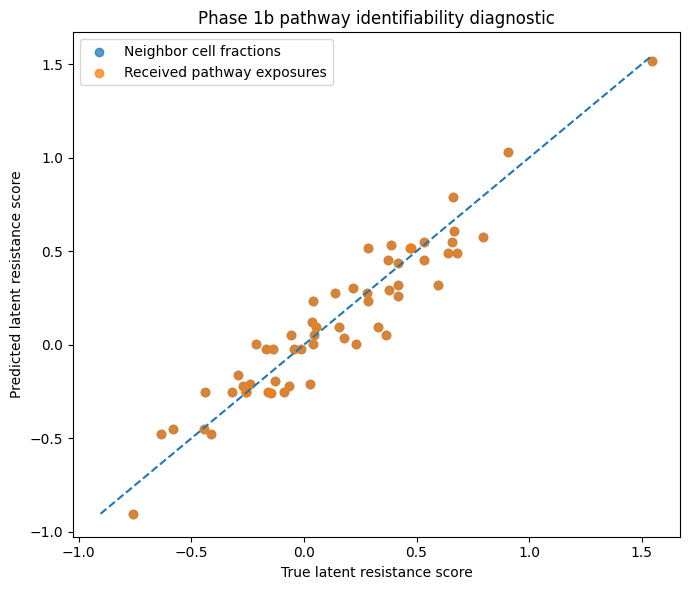

Latent-score reconstruction summary:
                   feature_set  n_features  train_r2  test_r2
    received_pathway_exposures           4    0.8979   0.9011
       neighbor_cell_fractions           5    0.8979   0.9011
combined_ecology_plus_pathways           9    0.8979   0.9011

Neighbor-cell-fraction coefficients:
            feature_set         feature  coefficient
neighbor_cell_fractions       nbr_tumor      -0.1193
neighbor_cell_fractions  nbr_fibroblast       1.9364
neighbor_cell_fractions  nbr_macrophage      -0.1156
neighbor_cell_fractions      nbr_t_cell      -1.9368
neighbor_cell_fractions nbr_endothelial       0.2353


In [21]:
# CELL 9 — Diagnose pathway non-identifiability by testing whether neighbor cell composition already predicts the true latent pathway score
# Purpose:
#   Show whether the current Phase 1b world can be solved from neighbor ecology alone,
#   without needing the gene→pathway mask.
#
# Interpretation target:
#   If neighbor cell fractions alone reconstruct the true latent resistance score very well,
#   then the pathway prior is not identifiable in the current benchmark.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


def _fit_linear_score_reconstruction(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
) -> Dict[str, np.ndarray]:
    reg = LinearRegression()
    reg.fit(X_train, y_train)

    pred_train = reg.predict(X_train)
    pred_test = reg.predict(X_test)

    return {
        "coef": reg.coef_.copy(),
        "intercept": float(reg.intercept_),
        "pred_train": pred_train,
        "pred_test": pred_test,
        "r2_train": float(r2_score(y_train, pred_train)),
        "r2_test": float(r2_score(y_test, pred_test)),
    }


def phase1b_pathway_identifiability_diagnostic(
    node_df: pd.DataFrame,
    data: Data,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compare how well different feature families reconstruct the true latent resistance score
    on tumor nodes only.
    """
    tumor_mask = (data.tumor_mask & data.labeled_mask).cpu().numpy().astype(bool)
    train_mask = (data.train_mask & data.tumor_mask & data.labeled_mask).cpu().numpy().astype(bool)
    test_mask = (data.test_mask & data.tumor_mask & data.labeled_mask).cpu().numpy().astype(bool)

    tumor_df = node_df.loc[tumor_mask].reset_index(drop=True).copy()

    # Rebuild aligned train/test masks within the tumor-only table
    tumor_train_mask = train_mask[tumor_mask]
    tumor_test_mask = test_mask[tumor_mask]

    # True latent score used to assign labels in the generator
    y_score = tumor_df["resistance_score"].to_numpy(dtype=np.float32)

    feature_sets = {
        "neighbor_cell_fractions": tumor_df[
            ["nbr_tumor", "nbr_fibroblast", "nbr_macrophage", "nbr_t_cell", "nbr_endothelial"]
        ].to_numpy(dtype=np.float32),

        "received_pathway_exposures": tumor_df[
            ["recv_TGFB", "recv_WNT", "recv_IFNG", "recv_AntigenPresentation"]
        ].to_numpy(dtype=np.float32),

        "combined_ecology_plus_pathways": tumor_df[
            [
                "nbr_tumor", "nbr_fibroblast", "nbr_macrophage", "nbr_t_cell", "nbr_endothelial",
                "recv_TGFB", "recv_WNT", "recv_IFNG", "recv_AntigenPresentation",
            ]
        ].to_numpy(dtype=np.float32),
    }

    summary_rows = []
    coef_rows = []

    for feature_name, X in feature_sets.items():
        fit = _fit_linear_score_reconstruction(
            X_train=X[tumor_train_mask],
            y_train=y_score[tumor_train_mask],
            X_test=X[tumor_test_mask],
            y_test=y_score[tumor_test_mask],
        )

        summary_rows.append({
            "feature_set": feature_name,
            "n_features": int(X.shape[1]),
            "train_r2": fit["r2_train"],
            "test_r2": fit["r2_test"],
        })

        if feature_name == "neighbor_cell_fractions":
            feature_labels = ["nbr_tumor", "nbr_fibroblast", "nbr_macrophage", "nbr_t_cell", "nbr_endothelial"]
        elif feature_name == "received_pathway_exposures":
            feature_labels = ["recv_TGFB", "recv_WNT", "recv_IFNG", "recv_AntigenPresentation"]
        else:
            feature_labels = [
                "nbr_tumor", "nbr_fibroblast", "nbr_macrophage", "nbr_t_cell", "nbr_endothelial",
                "recv_TGFB", "recv_WNT", "recv_IFNG", "recv_AntigenPresentation",
            ]

        for label, coef in zip(feature_labels, fit["coef"]):
            coef_rows.append({
                "feature_set": feature_name,
                "feature": label,
                "coefficient": float(coef),
            })

    summary_df = pd.DataFrame(summary_rows).sort_values("test_r2", ascending=False).reset_index(drop=True)
    coef_df = pd.DataFrame(coef_rows)

    # Plot: test-set scatter for the two most informative comparisons
    ecology_fit = _fit_linear_score_reconstruction(
        X_train=feature_sets["neighbor_cell_fractions"][tumor_train_mask],
        y_train=y_score[tumor_train_mask],
        X_test=feature_sets["neighbor_cell_fractions"][tumor_test_mask],
        y_test=y_score[tumor_test_mask],
    )
    pathway_fit = _fit_linear_score_reconstruction(
        X_train=feature_sets["received_pathway_exposures"][tumor_train_mask],
        y_train=y_score[tumor_train_mask],
        X_test=feature_sets["received_pathway_exposures"][tumor_test_mask],
        y_test=y_score[tumor_test_mask],
    )

    y_test = y_score[tumor_test_mask]

    plt.figure(figsize=(7, 6))
    plt.scatter(y_test, ecology_fit["pred_test"], alpha=0.75, label="Neighbor cell fractions")
    plt.scatter(y_test, pathway_fit["pred_test"], alpha=0.75, label="Received pathway exposures")
    lo = float(min(y_test.min(), ecology_fit["pred_test"].min(), pathway_fit["pred_test"].min()))
    hi = float(max(y_test.max(), ecology_fit["pred_test"].max(), pathway_fit["pred_test"].max()))
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("True latent resistance score")
    plt.ylabel("Predicted latent resistance score")
    plt.title("Phase 1b pathway identifiability diagnostic")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary_df, coef_df


phase1b_identifiability_summary, phase1b_identifiability_coefs = phase1b_pathway_identifiability_diagnostic(
    node_df=phase1b_true_nodes,
    data=phase1b_true_data,
)

print("Latent-score reconstruction summary:")
print(phase1b_identifiability_summary.round(4).to_string(index=False))

print("\nNeighbor-cell-fraction coefficients:")
print(
    phase1b_identifiability_coefs[
        phase1b_identifiability_coefs["feature_set"] == "neighbor_cell_fractions"
    ].round(4).to_string(index=False)
)

# 7. Phase 1c Benchmark: Mixed Pathway Emission Model

To ensure pathway identifiability, we modify the generator.

Changes:

- cell types emit **mixed pathway programs**
- pathway exposure is no longer determined by cell identity alone
- the model must aggregate gene signals to recover pathway structure

### Step 21

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [22]:
# CELL 10 — Phase 1c generator upgrade: decouple cell type from pathway program by using mixed pathway emissions
# Purpose:
#   Replace the deterministic cell-type -> pathway mapping with a probabilistic emission model.
#   This makes neighbor cell composition insufficient by itself and forces pathway aggregation
#   to become informative.
#
# What changes:
#   1. Each cell type emits a mixture of pathway signals rather than a single dominant program.
#   2. Neighbor-exposure scores are computed from emitted pathway signals, not directly from cell fractions.
#   3. The label remains a function of received pathway exposure, but pathway exposure is no longer
#      nearly recoverable from cell composition alone.

PHASE1C_EMISSION_MIXTURE = pd.DataFrame(
    {
        "TGFB": {
            "tumor": 0.30,
            "fibroblast": 0.60,
            "macrophage": 0.35,
            "t_cell": 0.10,
            "endothelial": 0.20,
        },
        "WNT": {
            "tumor": 0.45,
            "fibroblast": 0.20,
            "macrophage": 0.10,
            "t_cell": 0.10,
            "endothelial": 0.35,
        },
        "IFNG": {
            "tumor": 0.05,
            "fibroblast": 0.05,
            "macrophage": 0.15,
            "t_cell": 0.70,
            "endothelial": 0.05,
        },
        "AntigenPresentation": {
            "tumor": 0.20,
            "fibroblast": 0.10,
            "macrophage": 0.50,
            "t_cell": 0.20,
            "endothelial": 0.10,
        },
    }
).loc[PHASE1B_CELL_TYPES, PHASE1B_PATHWAYS]


def _compute_neighbor_exposure_table(
    cfg: Phase1BConfig,
    cell_type_ids: np.ndarray,
    edge_index: torch.Tensor,
) -> pd.DataFrame:
    """
    Phase 1c version:
      - keep neighbor cell fractions for auditing
      - generate per-node pathway emission mixtures from cell identity + stochastic heterogeneity
      - compute received pathway exposures from neighbor-emitted pathway signals

    This breaks the near-deterministic mapping:
        neighbor cell composition -> pathway exposure
    """
    rng = np.random.default_rng(cfg.seed + 404)

    # ---------------------------------------------------------
    # 1) Neighbor cell fractions (kept only for auditing / diagnostics)
    # ---------------------------------------------------------
    one_hot = np.zeros((cfg.n_nodes, len(cfg.cell_types)), dtype=np.float32)
    one_hot[np.arange(cfg.n_nodes), cell_type_ids] = 1.0
    nbr_frac = neighbor_mean_numpy(one_hot, edge_index)

    df = pd.DataFrame({
        "nbr_tumor": nbr_frac[:, PHASE1B_CELL_TYPE_TO_ID["tumor"]],
        "nbr_fibroblast": nbr_frac[:, PHASE1B_CELL_TYPE_TO_ID["fibroblast"]],
        "nbr_macrophage": nbr_frac[:, PHASE1B_CELL_TYPE_TO_ID["macrophage"]],
        "nbr_t_cell": nbr_frac[:, PHASE1B_CELL_TYPE_TO_ID["t_cell"]],
        "nbr_endothelial": nbr_frac[:, PHASE1B_CELL_TYPE_TO_ID["endothelial"]],
    })

    # ---------------------------------------------------------
    # 2) Cell-level emitted pathway programs
    # ---------------------------------------------------------
    # Base emission mixture by cell type
    base_emit = np.zeros((cfg.n_nodes, len(cfg.pathways)), dtype=np.float32)
    for ctype_name, ctype_id in PHASE1B_CELL_TYPE_TO_ID.items():
        rows = np.where(cell_type_ids == ctype_id)[0]
        if len(rows) == 0:
            continue
        base_emit[rows] = PHASE1C_EMISSION_MIXTURE.loc[ctype_name, cfg.pathways].to_numpy(dtype=np.float32)

    # Add cell-level heterogeneity so the same cell type does not always emit the same pathway mixture.
    # This is the key move that weakens identifiability from composition alone.
    heterogeneity = rng.lognormal(
        mean=0.0,
        sigma=0.45,
        size=base_emit.shape,
    ).astype(np.float32)

    emitted = base_emit * heterogeneity

    # Mild pathway-specific global scaling keeps the intended biological directions.
    pathway_scale = np.array([
        cfg.tgfb_from_fibro,
        cfg.wnt_from_stroma,
        cfg.ifng_from_tcells,
        cfg.ap_from_immune,
    ], dtype=np.float32)
    emitted = emitted * pathway_scale[None, :]

    # ---------------------------------------------------------
    # 3) Received pathway exposures from neighbors
    # ---------------------------------------------------------
    recv = neighbor_mean_numpy(emitted, edge_index).astype(np.float32)

    df["emit_TGFB"] = emitted[:, 0]
    df["emit_WNT"] = emitted[:, 1]
    df["emit_IFNG"] = emitted[:, 2]
    df["emit_AntigenPresentation"] = emitted[:, 3]

    df["recv_TGFB"] = recv[:, 0]
    df["recv_WNT"] = recv[:, 1]
    df["recv_IFNG"] = recv[:, 2]
    df["recv_AntigenPresentation"] = recv[:, 3]

    return df


# ---------------------------------------------------------
# Rebuild TRUE world with the Phase 1c exposure model
# ---------------------------------------------------------
phase1c_true_data, phase1c_true_nodes = generate_phase1b_true_world(PHASE1B_CONFIG)

print("Phase 1c TRUE world regenerated with mixed pathway emissions.")
print("Emission mixture used:")
print(PHASE1C_EMISSION_MIXTURE.round(2).to_string())

tumor_df = phase1c_true_nodes[phase1c_true_nodes["is_tumor"] == 1].copy()
print("\nTumor-only mean received pathway exposures by label:")
print(
    tumor_df.groupby("label")[["recv_TGFB", "recv_WNT", "recv_IFNG", "recv_AntigenPresentation"]]
    .mean()
    .round(3)
    .to_string()
)

Phase 1c TRUE world regenerated with mixed pathway emissions.
Emission mixture used:
             TGFB   WNT  IFNG  AntigenPresentation
tumor        0.30  0.45  0.05                  0.2
fibroblast   0.60  0.20  0.05                  0.1
macrophage   0.35  0.10  0.15                  0.5
t_cell       0.10  0.10  0.70                  0.2
endothelial  0.20  0.35  0.05                  0.1

Tumor-only mean received pathway exposures by label:
       recv_TGFB  recv_WNT  recv_IFNG  recv_AntigenPresentation
label                                                          
0          0.430     0.273      0.286                     0.266
1          0.539     0.333      0.145                     0.222


## 7.1 Pathway Identifiability Verification

We confirm that pathway exposures are no longer recoverable from simple cell composition features.

### Step 23

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


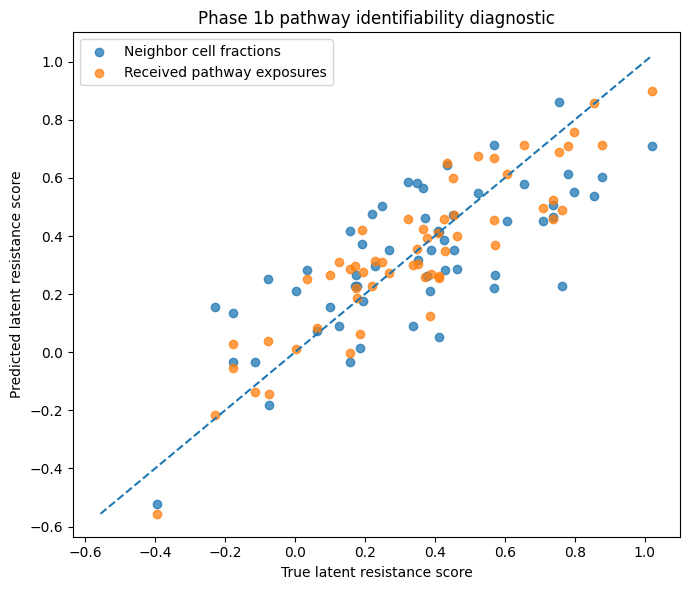

Phase 1c latent-score reconstruction summary:
                   feature_set  n_features  train_r2  test_r2
combined_ecology_plus_pathways           9    0.7877   0.8174
    received_pathway_exposures           4    0.7857   0.8113
       neighbor_cell_fractions           5    0.6151   0.5290

Neighbor-cell-fraction coefficients:
            feature_set         feature  coefficient
neighbor_cell_fractions       nbr_tumor       0.3945
neighbor_cell_fractions  nbr_fibroblast       0.9136
neighbor_cell_fractions  nbr_macrophage      -0.4489
neighbor_cell_fractions      nbr_t_cell      -1.1313
neighbor_cell_fractions nbr_endothelial       0.2722


In [23]:
# CELL 11 — Phase 1c pathway identifiability diagnostic
# Purpose:
#   Verify that neighbor cell composition alone can no longer
#   reconstruct the latent resistance score.

phase1c_ident_summary, phase1c_ident_coefs = phase1b_pathway_identifiability_diagnostic(
    node_df=phase1c_true_nodes,
    data=phase1c_true_data,
)

print("Phase 1c latent-score reconstruction summary:")
print(phase1c_ident_summary.round(4).to_string(index=False))

print("\nNeighbor-cell-fraction coefficients:")
print(
    phase1c_ident_coefs[
        phase1c_ident_coefs["feature_set"] == "neighbor_cell_fractions"
    ].round(4).to_string(index=False)
)

## 7.2 Phase 1c Falsification Worlds

New falsification environments are generated for the updated benchmark.

### Step 25

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [24]:
# CELL 12 — Build Phase 1c falsification worlds

phase1c_worlds = {}

true_world = phase1c_true_data

mask_shuffle_world = clone_data_with_updates(
    true_world,
    true_pathway_mask=shuffle_pathway_mask(true_world.true_pathway_mask, seed=PHASE1B_CONFIG.seed + 101),
    world_name="MASK_SHUFFLE",
)

spatial_null_world = clone_data_with_updates(
    true_world,
    edge_index=spatial_null_edge_index(
        coords=true_world.pos.cpu().numpy(),
        k=PHASE1B_CONFIG.k_neighbors,
        seed=PHASE1B_CONFIG.seed + 202,
    ),
    world_name="SPATIAL_NULL",
)

pathway_null_world = clone_data_with_updates(
    true_world,
    true_pathway_mask=dense_pathway_null_mask(
        n_genes=true_world.x.shape[1],
        n_pathways=true_world.true_pathway_mask.shape[1],
    ),
    world_name="PATHWAY_NULL",
)

phase1c_worlds["TRUE"] = true_world
phase1c_worlds["MASK_SHUFFLE"] = mask_shuffle_world
phase1c_worlds["SPATIAL_NULL"] = spatial_null_world
phase1c_worlds["PATHWAY_NULL"] = pathway_null_world

summary_rows = []
for name, world in phase1c_worlds.items():
    summary_rows.append({
        "world": name,
        "nodes": int(world.num_nodes),
        "edges": int(world.edge_index.shape[1]),
        "mask_density": float(world.true_pathway_mask.mean()),
    })

print(pd.DataFrame(summary_rows))

          world  nodes  edges  mask_density
0          TRUE    900   7200      0.083333
1  MASK_SHUFFLE    900   7200      0.083333
2  SPATIAL_NULL    900   7200      0.083333
3  PATHWAY_NULL    900   7200      1.000000


#### Output interpretation
- Compare results to falsification expectations
- Look for separation between TRUE vs NULL conditions
- Strong separation indicates meaningful signal usage


# 8. Baseline Evaluation on Phase 1c Benchmark

Baseline models are re-evaluated to confirm the benchmark behaves correctly under the new generator.

### Step 27

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [25]:
# CELL 13 — Phase 1c baseline evaluation

phase1c_baseline_results = evaluate_baselines_across_worlds(
    worlds=phase1c_worlds,
    baseline_views=[
        "local_only",
        "neighbor_only",
        "local_plus_neighbor",
    ],
    seed=PHASE1B_CONFIG.seed,
)

print("Phase 1c baseline results:")
print(phase1c_baseline_results.round(4).to_string(index=False))

print("\nPivot AUROC:")
print(
    phase1c_baseline_results
    .pivot(index="baseline", columns="world", values="auroc")
    .round(4)
)

print("\nPivot F1:")
print(
    phase1c_baseline_results
    .pivot(index="baseline", columns="world", values="f1")
    .round(4)
)

Phase 1c baseline results:
       world            baseline  n_train  n_test     f1  auroc  auprc
MASK_SHUFFLE          local_only      197      58 0.5397 0.5854 0.6898
PATHWAY_NULL          local_only      197      58 0.5397 0.5854 0.6898
SPATIAL_NULL          local_only      197      58 0.5397 0.5854 0.6898
        TRUE          local_only      197      58 0.5397 0.5854 0.6898
MASK_SHUFFLE local_plus_neighbor      197      58 0.7241 0.8100 0.8440
PATHWAY_NULL local_plus_neighbor      197      58 0.7241 0.8100 0.8440
SPATIAL_NULL local_plus_neighbor      197      58 0.5161 0.5042 0.5856
        TRUE local_plus_neighbor      197      58 0.7241 0.8100 0.8440
MASK_SHUFFLE       neighbor_only      197      58 0.7742 0.8554 0.8830
PATHWAY_NULL       neighbor_only      197      58 0.7742 0.8554 0.8830
SPATIAL_NULL       neighbor_only      197      58 0.4286 0.4373 0.5126
        TRUE       neighbor_only      197      58 0.7742 0.8554 0.8830

Pivot AUROC:
world                MASK_SHUFFLE  P

# 9. Spatial-MMKPNN Evaluation on Phase 1c Worlds

### Step 29

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [26]:
# CELL 14 — Spatial-MMKPNN evaluation on Phase 1c worlds

phase1c_model_runs = {}
phase1c_model_rows = []
phase1c_alignment_rows = []

for world_name, world_data in phase1c_worlds.items():

    result = train_one_world_spatial_mmkpnn(
        data=world_data,
        seed=PHASE1B_CONFIG.seed,
        learning_rate=0.002,
        pathway_sparsity_lambda=0.001,
        epochs=80,
        concept_mode="neighbor_only",
        verbose=False,
    )

    phase1c_model_runs[world_name] = result
    phase1c_model_rows.append(result["summary"])

    align_df = result["alignment"].copy()
    align_df["world"] = world_name
    phase1c_alignment_rows.append(align_df)

phase1c_model_results = pd.DataFrame(phase1c_model_rows).sort_values("world")

print("Phase 1c Spatial-MMKPNN results:")
print(
    phase1c_model_results[
        ["world","test_f1","test_auroc","test_auprc","pathway_sign_match_mean"]
    ].round(4)
)

true_f1 = float(phase1c_model_results.loc[phase1c_model_results.world=="TRUE","test_f1"])
mask_f1 = float(phase1c_model_results.loc[phase1c_model_results.world=="MASK_SHUFFLE","test_f1"])
spatial_f1 = float(phase1c_model_results.loc[phase1c_model_results.world=="SPATIAL_NULL","test_f1"])
pathnull_f1 = float(phase1c_model_results.loc[phase1c_model_results.world=="PATHWAY_NULL","test_f1"])

print("\nFalsification gaps:")
print("TRUE - MASK_SHUFFLE:", true_f1-mask_f1)
print("TRUE - PATHWAY_NULL:", true_f1-pathnull_f1)
print("TRUE - SPATIAL_NULL:", true_f1-spatial_f1)

Phase 1c Spatial-MMKPNN results:
          world  test_f1  test_auroc  test_auprc  pathway_sign_match_mean
1  MASK_SHUFFLE   0.6970      0.6965      0.7049                      0.5
3  PATHWAY_NULL   0.5172      0.5460      0.6209                      0.5
2  SPATIAL_NULL   0.5797      0.4886      0.5376                      0.5
0          TRUE   0.3860      0.2951      0.4268                      1.0

Falsification gaps:
TRUE - MASK_SHUFFLE: -0.3110047846889953
TRUE - PATHWAY_NULL: -0.13127646702964313
TRUE - SPATIAL_NULL: -0.19374523264683452


/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_81859/37239598.py:35: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  true_f1 = float(phase1c_model_results.loc[phase1c_model_results.world=="TRUE","test_f1"])
/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_81859/37239598.py:36: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mask_f1 = float(phase1c_model_results.loc[phase1c_model_results.world=="MASK_SHUFFLE","test_f1"])
/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_81859/37239598.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spatial_f1 = float(phase1c_model_results.loc[phase1c_model_results.world=="SPATIAL_NULL","test_f1"])
/var/folders/r2/x9gghyl142nb0hbyp

# 8. Baseline Evaluation on Phase 1c Benchmark

Baseline models are re-evaluated to confirm the benchmark behaves correctly under the new generator.

### Step 31

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [27]:
# CELL 15 — spatial MLP baseline (no pathway bottleneck)

class SpatialMLP(nn.Module):

    def __init__(self, n_genes):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(n_genes, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def mean_neighbors(self, x, edge_index):

        src, dst = edge_index
        out = torch.zeros_like(x)
        deg = torch.zeros(x.shape[0], device=x.device)

        out.index_add_(0, dst, x[src])
        deg.index_add_(0, dst, torch.ones_like(dst, dtype=x.dtype))

        deg = deg.clamp_min(1).unsqueeze(1)

        return out / deg

    def forward(self, x, edge_index):

        neighbor_x = self.mean_neighbors(x, edge_index)

        return self.mlp(neighbor_x)

# 10. Spatial Gene-Level Baseline

A spatial MLP without pathway bottleneck is evaluated to test whether the dataset itself is learnable.

### Step 33

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [28]:
# CELL 16 — Train and evaluate SpatialMLP across Phase 1c worlds

def train_spatial_mlp(data, seed, lr=0.002, epochs=80):

    set_seed(seed)

    model = SpatialMLP(data.x.shape[1]).to(DEVICE)
    d = copy.deepcopy(data).to(DEVICE)

    train_mask = d.train_mask & d.tumor_mask & d.labeled_mask
    val_mask = d.val_mask & d.tumor_mask & d.labeled_mask
    test_mask = d.test_mask & d.tumor_mask & d.labeled_mask

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = -1
    best_state = None

    for epoch in range(epochs):

        model.train()
        opt.zero_grad()

        logits = model(d.x, d.edge_index)
        loss = F.cross_entropy(logits[train_mask], d.y[train_mask])

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():

            logits_eval = model(d.x, d.edge_index)
            val_metrics = evaluate_logits_with_mask(logits_eval, d.y, val_mask)

        if val_metrics["f1"] > best_val:
            best_val = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        logits_final = model(d.x, d.edge_index)

    test_metrics = evaluate_logits_with_mask(logits_final, d.y, test_mask)

    return test_metrics


rows = []

for world_name, world_data in phase1c_worlds.items():

    metrics = train_spatial_mlp(
        world_data,
        seed=PHASE1B_CONFIG.seed
    )

    rows.append({
        "world": world_name,
        **metrics
    })

spatial_mlp_results = pd.DataFrame(rows)

print("\nSpatialMLP results:")
print(spatial_mlp_results.round(4))

print("\nPivot AUROC:")
print(spatial_mlp_results.pivot(columns="world", values="auroc"))

print("\nPivot F1:")
print(spatial_mlp_results.pivot(columns="world", values="f1"))


SpatialMLP results:
          world      f1   auroc   auprc
0          TRUE  0.7812  0.8447  0.8683
1  MASK_SHUFFLE  0.7812  0.8447  0.8683
2  SPATIAL_NULL  0.3704  0.4385  0.5350
3  PATHWAY_NULL  0.7812  0.8447  0.8683

Pivot AUROC:
world  MASK_SHUFFLE  PATHWAY_NULL  SPATIAL_NULL      TRUE
0               NaN           NaN           NaN  0.844683
1          0.844683           NaN           NaN       NaN
2               NaN           NaN      0.438471       NaN
3               NaN      0.844683           NaN       NaN

Pivot F1:
world  MASK_SHUFFLE  PATHWAY_NULL  SPATIAL_NULL     TRUE
0               NaN           NaN           NaN  0.78125
1           0.78125           NaN           NaN      NaN
2               NaN           NaN       0.37037      NaN
3               NaN       0.78125           NaN      NaN


# 11. Corrected Architecture: Spatial → Pathway Ordering

This experiment tests whether pathway compression should occur **after spatial aggregation** rather than before.

### Step 35

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [29]:
# CELL 17 — Corrected architecture: spatial aggregation before pathway projection
# Purpose:
#   Test whether the failure came from compressing genes into pathways too early.
#
# New ordering:
#   gene expression
#       ↓
#   neighbor aggregation in gene space
#       ↓
#   masked gene→pathway projection
#       ↓
#   classifier
#
# This preserves gene-level spatial signal before concept compression.

class SpatialThenPathwayMMKPNN(nn.Module):
    def __init__(
        self,
        n_genes: int,
        n_pathways: int,
        pathway_mask: torch.Tensor,
        classifier_input: str = "concept",   # {"concept", "local_plus_concept"}
        init_scale: float = 0.02,
    ):
        super().__init__()

        if classifier_input not in {"concept", "local_plus_concept"}:
            raise ValueError("classifier_input must be 'concept' or 'local_plus_concept'")

        self.classifier_input = classifier_input
        self.register_buffer("pathway_mask", pathway_mask.float())

        self.gene_to_pathway_raw = nn.Parameter(
            torch.randn(n_genes, n_pathways) * init_scale
        )

        classifier_dim = n_pathways if classifier_input == "concept" else (2 * n_pathways)
        self.classifier = nn.Linear(classifier_dim, 2)

    def masked_weight(self) -> torch.Tensor:
        return F.softplus(self.gene_to_pathway_raw) * self.pathway_mask

    @staticmethod
    def mean_neighbors(values: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index
        out = torch.zeros_like(values)
        deg = torch.zeros(values.shape[0], dtype=values.dtype, device=values.device)

        out.index_add_(0, dst, values[src])
        deg.index_add_(0, dst, torch.ones_like(dst, dtype=values.dtype))

        deg = deg.clamp_min(1.0).unsqueeze(1)
        return out / deg

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        W = self.masked_weight()

        # Local pathway activity for optional use / interpretation
        local_pathway = x @ W

        # Critical change: aggregate in gene space first
        neighbor_gene = self.mean_neighbors(x, edge_index)
        concept = neighbor_gene @ W

        if self.classifier_input == "concept":
            clf_input = concept
        else:
            clf_input = torch.cat([local_pathway, concept], dim=1)

        logits = self.classifier(clf_input)
        return logits, concept, local_pathway, W


def train_spatial_then_pathway(
    data: Data,
    seed: int,
    classifier_input: str = "concept",
    learning_rate: float = 0.002,
    pathway_sparsity_lambda: float = 0.001,
    epochs: int = 80,
):
    set_seed(seed)

    model = SpatialThenPathwayMMKPNN(
        n_genes=data.x.shape[1],
        n_pathways=data.true_pathway_mask.shape[1],
        pathway_mask=data.true_pathway_mask,
        classifier_input=classifier_input,
    ).to(DEVICE)

    d = copy.deepcopy(data).to(DEVICE)

    train_mask = d.train_mask & d.tumor_mask & d.labeled_mask
    val_mask = d.val_mask & d.tumor_mask & d.labeled_mask
    test_mask = d.test_mask & d.tumor_mask & d.labeled_mask

    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_val = -np.inf
    best_state = None

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()

        logits, concept, local_pathway, W = model(d.x, d.edge_index)
        ce = F.cross_entropy(logits[train_mask], d.y[train_mask])
        sparsity = pathway_sparsity_lambda * W.sum()
        loss = ce + sparsity

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            logits_eval, concept_eval, local_eval, W_eval = model(d.x, d.edge_index)
            val_metrics = evaluate_logits_with_mask(logits_eval, d.y, val_mask)

        if val_metrics["f1"] > best_val:
            best_val = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        logits_final, concept_final, local_final, W_final = model(d.x, d.edge_index)

    test_metrics = evaluate_logits_with_mask(logits_final, d.y, test_mask)
    alignment_df = compute_pathway_sign_alignment(
        concept_act=concept_final,
        y=d.y,
        mask=test_mask,
        pathway_names=list(d.pathway_names),
        expected_direction_map=dict(d.expected_directions),
    )

    return {
        "f1": test_metrics["f1"],
        "auroc": test_metrics["auroc"],
        "auprc": test_metrics["auprc"],
        "pathway_sign_match_mean": float(alignment_df["sign_match"].mean()),
        "alignment": alignment_df,
    }


# ---------------------------------------------------------
# Evaluate corrected ordering on all Phase 1c worlds
# ---------------------------------------------------------
rows = []
alignment_rows = []

for world_name, world_data in phase1c_worlds.items():
    result = train_spatial_then_pathway(
        data=world_data,
        seed=PHASE1B_CONFIG.seed,
        classifier_input="concept",
        learning_rate=0.002,
        pathway_sparsity_lambda=0.001,
        epochs=80,
    )

    rows.append({
        "world": world_name,
        "f1": result["f1"],
        "auroc": result["auroc"],
        "auprc": result["auprc"],
        "pathway_sign_match_mean": result["pathway_sign_match_mean"],
    })

    align_df = result["alignment"].copy()
    align_df["world"] = world_name
    alignment_rows.append(align_df)

phase1c_corrected_results = pd.DataFrame(rows).sort_values("world").reset_index(drop=True)
phase1c_corrected_alignment = pd.concat(alignment_rows, ignore_index=True)

print("Corrected-order Spatial→Pathway MMKPNN results:")
print(phase1c_corrected_results.round(4).to_string(index=False))

true_f1 = float(phase1c_corrected_results.loc[phase1c_corrected_results["world"] == "TRUE", "f1"].iloc[0])
mask_f1 = float(phase1c_corrected_results.loc[phase1c_corrected_results["world"] == "MASK_SHUFFLE", "f1"].iloc[0])
spatial_f1 = float(phase1c_corrected_results.loc[phase1c_corrected_results["world"] == "SPATIAL_NULL", "f1"].iloc[0])
pathnull_f1 = float(phase1c_corrected_results.loc[phase1c_corrected_results["world"] == "PATHWAY_NULL", "f1"].iloc[0])

print("\nFalsification gaps (F1):")
print(f"TRUE - MASK_SHUFFLE = {true_f1 - mask_f1:.4f}")
print(f"TRUE - PATHWAY_NULL = {true_f1 - pathnull_f1:.4f}")
print(f"TRUE - SPATIAL_NULL = {true_f1 - spatial_f1:.4f}")

print("\nPathway sign alignment:")
print(
    phase1c_corrected_alignment[
        ["world", "pathway", "delta_resistant_minus_sensitive", "expected_direction", "observed_direction", "sign_match"]
    ].round(4).to_string(index=False)
)

Corrected-order Spatial→Pathway MMKPNN results:
       world     f1  auroc  auprc  pathway_sign_match_mean
MASK_SHUFFLE 0.6970 0.6965 0.7049                      0.5
PATHWAY_NULL 0.5172 0.5460 0.6209                      0.5
SPATIAL_NULL 0.5797 0.4886 0.5376                      0.5
        TRUE 0.3860 0.2951 0.4268                      1.0

Falsification gaps (F1):
TRUE - MASK_SHUFFLE = -0.3110
TRUE - PATHWAY_NULL = -0.1313
TRUE - SPATIAL_NULL = -0.1937

Pathway sign alignment:
       world             pathway  delta_resistant_minus_sensitive expected_direction observed_direction  sign_match
        TRUE                TGFB                           0.5284                 up                 up        True
        TRUE                 WNT                           0.0295                 up                 up        True
        TRUE                IFNG                          -1.1214               down               down        True
        TRUE AntigenPresentation                    

#### Output interpretation
- Compare results to falsification expectations
- Look for separation between TRUE vs NULL conditions
- Strong separation indicates meaningful signal usage


# 12. Hybrid Spatial–Pathway Architecture

The hybrid model preserves gene-level spatial information while adding interpretable pathway concepts.

Pipeline:

gene expression  
↓  
neighbor aggregation  
↓  
pathway concept projection  
↓  
classifier

### Step 37

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [30]:
# CELL 18 — Hybrid architecture: preserve gene-level spatial signal and add pathway concepts as interpretable auxiliary features
# Purpose:
#   Test the architecture that the diagnostics now motivate:
#
#     neighbor gene features
#            +
#     masked pathway concepts
#            ↓
#        classifier
#
#   This keeps predictive gene-level spatial information available to the classifier,
#   while still learning interpretable pathway concepts through the biological mask.

class HybridSpatialPathwayNet(nn.Module):
    def __init__(
        self,
        n_genes: int,
        n_pathways: int,
        pathway_mask: torch.Tensor,
        hidden_dim: int = 64,
        init_scale: float = 0.02,
    ):
        super().__init__()

        self.n_genes = n_genes
        self.n_pathways = n_pathways

        self.register_buffer("pathway_mask", pathway_mask.float())

        # Interpretable masked pathway projection
        self.gene_to_pathway_raw = nn.Parameter(
            torch.randn(n_genes, n_pathways) * init_scale
        )

        # Hybrid classifier: gene-level spatial features + pathway concepts
        self.classifier = nn.Sequential(
            nn.Linear(n_genes + n_pathways, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),
        )

    def masked_weight(self) -> torch.Tensor:
        return F.softplus(self.gene_to_pathway_raw) * self.pathway_mask

    @staticmethod
    def mean_neighbors(values: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index
        out = torch.zeros_like(values)
        deg = torch.zeros(values.shape[0], dtype=values.dtype, device=values.device)

        out.index_add_(0, dst, values[src])
        deg.index_add_(0, dst, torch.ones_like(dst, dtype=values.dtype))

        deg = deg.clamp_min(1.0).unsqueeze(1)
        return out / deg

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        W = self.masked_weight()

        # Preserve full spatial gene signal
        neighbor_gene = self.mean_neighbors(x, edge_index)

        # Interpretable pathway concepts derived from spatial gene signal
        pathway_concept = neighbor_gene @ W

        # Hybrid predictor
        hybrid_feat = torch.cat([neighbor_gene, pathway_concept], dim=1)
        logits = self.classifier(hybrid_feat)

        return logits, pathway_concept, neighbor_gene, W


def train_hybrid_spatial_pathway(
    data: Data,
    seed: int,
    learning_rate: float = 0.002,
    pathway_sparsity_lambda: float = 0.001,
    epochs: int = 80,
    hidden_dim: int = 64,
):
    set_seed(seed)

    model = HybridSpatialPathwayNet(
        n_genes=data.x.shape[1],
        n_pathways=data.true_pathway_mask.shape[1],
        pathway_mask=data.true_pathway_mask,
        hidden_dim=hidden_dim,
    ).to(DEVICE)

    d = copy.deepcopy(data).to(DEVICE)

    train_mask = d.train_mask & d.tumor_mask & d.labeled_mask
    val_mask = d.val_mask & d.tumor_mask & d.labeled_mask
    test_mask = d.test_mask & d.tumor_mask & d.labeled_mask

    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_val = -np.inf
    best_state = None

    for epoch in range(epochs):
        model.train()
        opt.zero_grad()

        logits, pathway_concept, neighbor_gene, W = model(d.x, d.edge_index)

        ce = F.cross_entropy(logits[train_mask], d.y[train_mask])
        sparsity = pathway_sparsity_lambda * W.sum()
        loss = ce + sparsity

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            logits_eval, concept_eval, ng_eval, W_eval = model(d.x, d.edge_index)
            val_metrics = evaluate_logits_with_mask(logits_eval, d.y, val_mask)

        if val_metrics["f1"] > best_val:
            best_val = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        logits_final, concept_final, neighbor_gene_final, W_final = model(d.x, d.edge_index)

    test_metrics = evaluate_logits_with_mask(logits_final, d.y, test_mask)

    alignment_df = compute_pathway_sign_alignment(
        concept_act=concept_final,
        y=d.y,
        mask=test_mask,
        pathway_names=list(d.pathway_names),
        expected_direction_map=dict(d.expected_directions),
    )

    return {
        "f1": test_metrics["f1"],
        "auroc": test_metrics["auroc"],
        "auprc": test_metrics["auprc"],
        "pathway_sign_match_mean": float(alignment_df["sign_match"].mean()),
        "alignment": alignment_df,
    }


# ---------------------------------------------------------
# Evaluate hybrid architecture on Phase 1c worlds
# ---------------------------------------------------------
hybrid_rows = []
hybrid_alignment_rows = []

for world_name, world_data in phase1c_worlds.items():
    result = train_hybrid_spatial_pathway(
        data=world_data,
        seed=PHASE1B_CONFIG.seed,
        learning_rate=0.002,
        pathway_sparsity_lambda=0.001,
        epochs=80,
        hidden_dim=64,
    )

    hybrid_rows.append({
        "world": world_name,
        "f1": result["f1"],
        "auroc": result["auroc"],
        "auprc": result["auprc"],
        "pathway_sign_match_mean": result["pathway_sign_match_mean"],
    })

    align_df = result["alignment"].copy()
    align_df["world"] = world_name
    hybrid_alignment_rows.append(align_df)

phase1c_hybrid_results = pd.DataFrame(hybrid_rows).sort_values("world").reset_index(drop=True)
phase1c_hybrid_alignment = pd.concat(hybrid_alignment_rows, ignore_index=True)

print("Hybrid Spatial+Pathway results:")
print(phase1c_hybrid_results.round(4).to_string(index=False))

true_f1 = float(phase1c_hybrid_results.loc[phase1c_hybrid_results["world"] == "TRUE", "f1"].iloc[0])
mask_f1 = float(phase1c_hybrid_results.loc[phase1c_hybrid_results["world"] == "MASK_SHUFFLE", "f1"].iloc[0])
spatial_f1 = float(phase1c_hybrid_results.loc[phase1c_hybrid_results["world"] == "SPATIAL_NULL", "f1"].iloc[0])
pathnull_f1 = float(phase1c_hybrid_results.loc[phase1c_hybrid_results["world"] == "PATHWAY_NULL", "f1"].iloc[0])

print("\nFalsification gaps (F1):")
print(f"TRUE - MASK_SHUFFLE = {true_f1 - mask_f1:.4f}")
print(f"TRUE - PATHWAY_NULL = {true_f1 - pathnull_f1:.4f}")
print(f"TRUE - SPATIAL_NULL = {true_f1 - spatial_f1:.4f}")

print("\nPathway sign alignment:")
print(
    phase1c_hybrid_alignment[
        ["world", "pathway", "delta_resistant_minus_sensitive", "expected_direction", "observed_direction", "sign_match"]
    ].round(4).to_string(index=False)
)

Hybrid Spatial+Pathway results:
       world     f1  auroc  auprc  pathway_sign_match_mean
MASK_SHUFFLE 0.8286 0.8387 0.8300                      0.5
PATHWAY_NULL 0.7164 0.7897 0.7914                      0.5
SPATIAL_NULL 0.3636 0.4122 0.5282                      0.5
        TRUE 0.7576 0.8220 0.8200                      1.0

Falsification gaps (F1):
TRUE - MASK_SHUFFLE = -0.0710
TRUE - PATHWAY_NULL = 0.0412
TRUE - SPATIAL_NULL = 0.3939

Pathway sign alignment:
       world             pathway  delta_resistant_minus_sensitive expected_direction observed_direction  sign_match
        TRUE                TGFB                           0.5277                 up                 up        True
        TRUE                 WNT                           0.0261                 up                 up        True
        TRUE                IFNG                          -1.1741               down               down        True
        TRUE AntigenPresentation                          -0.6165     

# 13. Multi-Seed Validation

To ensure robustness, the hybrid model is evaluated across multiple random seeds.

Metrics reported:

- predictive performance
- falsification consistency
- pathway sign recovery

### Step 39

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [31]:
# CELL 19 — Multi-seed hybrid-model validation sweep for Phase 1c
# Purpose:
#   Run the Hybrid Spatial+Pathway model across multiple seeds and all falsification worlds,
#   then summarize predictive stability, falsification consistency, and pathway sign recovery.

SEED_LIST = [11, 17, 23]

def build_phase1c_worlds_for_seed(seed: int) -> Dict[str, Data]:
    cfg_seed = Phase1BConfig(**{**PHASE1B_CONFIG.__dict__, "seed": seed})
    true_data, true_nodes = generate_phase1b_true_world(cfg_seed)

    worlds = {
        "TRUE": true_data,
        "MASK_SHUFFLE": clone_data_with_updates(
            true_data,
            true_pathway_mask=shuffle_pathway_mask(true_data.true_pathway_mask, seed=seed + 101),
            world_name="MASK_SHUFFLE",
        ),
        "SPATIAL_NULL": clone_data_with_updates(
            true_data,
            edge_index=spatial_null_edge_index(
                coords=true_data.pos.cpu().numpy(),
                k=cfg_seed.k_neighbors,
                seed=seed + 202,
            ),
            world_name="SPATIAL_NULL",
        ),
        "PATHWAY_NULL": clone_data_with_updates(
            true_data,
            true_pathway_mask=dense_pathway_null_mask(
                n_genes=true_data.x.shape[1],
                n_pathways=true_data.true_pathway_mask.shape[1],
            ),
            world_name="PATHWAY_NULL",
        ),
    }
    return worlds


seed_world_rows = []
seed_alignment_rows = []

for seed in SEED_LIST:
    worlds = build_phase1c_worlds_for_seed(seed)

    for world_name, world_data in worlds.items():
        result = train_hybrid_spatial_pathway(
            data=world_data,
            seed=seed,
            learning_rate=0.002,
            pathway_sparsity_lambda=0.001,
            epochs=80,
            hidden_dim=64,
        )

        seed_world_rows.append({
            "seed": seed,
            "world": world_name,
            "f1": result["f1"],
            "auroc": result["auroc"],
            "auprc": result["auprc"],
            "pathway_sign_match_mean": result["pathway_sign_match_mean"],
        })

        align_df = result["alignment"].copy()
        align_df["seed"] = seed
        align_df["world"] = world_name
        seed_alignment_rows.append(align_df)

phase1c_multiseed_results = pd.DataFrame(seed_world_rows).sort_values(["seed", "world"]).reset_index(drop=True)
phase1c_multiseed_alignment = pd.concat(seed_alignment_rows, ignore_index=True)

print("Phase 1c multi-seed hybrid-model results:")
print(phase1c_multiseed_results.round(4).to_string(index=False))

# ---------------------------------------------------------
# Seed-level falsification checks
# ---------------------------------------------------------
pivot_f1 = phase1c_multiseed_results.pivot(index="seed", columns="world", values="f1")
pivot_auroc = phase1c_multiseed_results.pivot(index="seed", columns="world", values="auroc")
pivot_sign = phase1c_multiseed_results.pivot(index="seed", columns="world", values="pathway_sign_match_mean")

seed_level_checks = pd.DataFrame({
    "TRUE_f1": pivot_f1["TRUE"],
    "MASK_f1": pivot_f1["MASK_SHUFFLE"],
    "SPATIAL_NULL_f1": pivot_f1["SPATIAL_NULL"],
    "PATHWAY_NULL_f1": pivot_f1["PATHWAY_NULL"],
    "TRUE_gt_MASK": pivot_f1["TRUE"] > pivot_f1["MASK_SHUFFLE"],
    "TRUE_gt_SPATIAL_NULL": pivot_f1["TRUE"] > pivot_f1["SPATIAL_NULL"],
    "TRUE_gt_PATHWAY_NULL": pivot_f1["TRUE"] > pivot_f1["PATHWAY_NULL"],
    "TRUE_sign_match": pivot_sign["TRUE"],
    "MASK_sign_match": pivot_sign["MASK_SHUFFLE"],
    "SPATIAL_NULL_sign_match": pivot_sign["SPATIAL_NULL"],
    "PATHWAY_NULL_sign_match": pivot_sign["PATHWAY_NULL"],
}).reset_index()

print("\nSeed-level falsification checks:")
print(seed_level_checks.to_string(index=False))

# ---------------------------------------------------------
# Summary tables
# ---------------------------------------------------------
summary_metrics = (
    phase1c_multiseed_results
    .groupby("world")[["f1", "auroc", "auprc", "pathway_sign_match_mean"]]
    .agg(["mean", "std"])
    .round(4)
)

print("\nWorld-level summary (mean ± sd):")
print(summary_metrics.to_string())

pass_fail_summary = pd.DataFrame({
    "criterion": [
        "TRUE > MASK_SHUFFLE",
        "TRUE > SPATIAL_NULL",
        "TRUE > PATHWAY_NULL",
    ],
    "passes": [
        int(seed_level_checks["TRUE_gt_MASK"].sum()),
        int(seed_level_checks["TRUE_gt_SPATIAL_NULL"].sum()),
        int(seed_level_checks["TRUE_gt_PATHWAY_NULL"].sum()),
    ],
    "total_seeds": [len(SEED_LIST)] * 3,
})

print("\nFalsification pass counts:")
print(pass_fail_summary.to_string(index=False))

# ---------------------------------------------------------
# Pathway-level stability in TRUE world
# ---------------------------------------------------------
true_alignment_summary = (
    phase1c_multiseed_alignment[phase1c_multiseed_alignment["world"] == "TRUE"]
    .groupby("pathway")[["delta_resistant_minus_sensitive", "sign_match"]]
    .agg(["mean", "std"])
    .round(4)
)

print("\nTRUE-world pathway alignment stability:")
print(true_alignment_summary.to_string())

Phase 1c multi-seed hybrid-model results:
 seed        world     f1  auroc  auprc  pathway_sign_match_mean
   11 MASK_SHUFFLE 0.8286 0.8387 0.8300                     0.50
   11 PATHWAY_NULL 0.7164 0.7897 0.7914                     0.50
   11 SPATIAL_NULL 0.3636 0.4122 0.5282                     0.50
   11         TRUE 0.7576 0.8220 0.8200                     1.00
   17 MASK_SHUFFLE 0.7895 0.8819 0.8973                     1.00
   17 PATHWAY_NULL 0.8000 0.8586 0.8623                     0.50
   17 SPATIAL_NULL 0.3692 0.5014 0.6738                     0.00
   17         TRUE 0.8250 0.8595 0.8911                     0.75
   23 MASK_SHUFFLE 0.7692 0.8295 0.7718                     0.75
   23 PATHWAY_NULL 0.7250 0.8122 0.8004                     0.50
   23 SPATIAL_NULL 0.5205 0.5114 0.5065                     1.00
   23         TRUE 0.7848 0.8385 0.7946                     1.00

Seed-level falsification checks:
 seed  TRUE_f1  MASK_f1  SPATIAL_NULL_f1  PATHWAY_NULL_f1  TRUE_gt_MASK  TRUE_g

### Step 40

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [32]:
# CELL 19.5 — Initialize Phase 1c dataset once for visualization cells

print("Initializing Phase 1c dataset...")

GLOBAL_SEED = 11

set_seed(GLOBAL_SEED)

phase1c_worlds_seed = build_phase1c_worlds_for_seed(GLOBAL_SEED)

TRUE_WORLD = phase1c_worlds_seed["TRUE"]
MASK_WORLD = phase1c_worlds_seed["MASK_SHUFFLE"]
SPATIAL_WORLD = phase1c_worlds_seed["SPATIAL_NULL"]
PATHWAY_WORLD = phase1c_worlds_seed["PATHWAY_NULL"]

print("Dataset ready.")
print("Nodes:", TRUE_WORLD.x.shape[0])
print("Edges:", TRUE_WORLD.edge_index.shape[1])

Initializing Phase 1c dataset...
Dataset ready.
Nodes: 900
Edges: 7200


#### Output interpretation
- Compare results to falsification expectations
- Look for separation between TRUE vs NULL conditions
- Strong separation indicates meaningful signal usage


# 14. Spatial Communication Program Visualization

Using the trained hybrid model, we extract pathway activations and visualize spatial signaling programs across the tissue.

### Step 42

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


In [33]:
# CELL 20 — Stable training and visualization artifacts
# Avoids deepcopy and large graph retention

import torch
import pandas as pd
import numpy as np

viz_data = TRUE_WORLD

# move data to device safely
d = viz_data.to(DEVICE)

model = HybridSpatialPathwayNet(
    n_genes=d.x.shape[1],
    n_pathways=d.true_pathway_mask.shape[1],
    pathway_mask=d.true_pathway_mask,
    hidden_dim=64,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

train_mask = d.train_mask & d.tumor_mask & d.labeled_mask
val_mask = d.val_mask & d.tumor_mask & d.labeled_mask
test_mask = d.test_mask & d.tumor_mask & d.labeled_mask

best_val = -1
best_state = None

for epoch in range(80):

    model.train()
    optimizer.zero_grad()

    logits, concept, neighbor_gene, W = model(d.x, d.edge_index)

    ce = torch.nn.functional.cross_entropy(logits[train_mask], d.y[train_mask])
    sparsity = 0.001 * W.sum()

    loss = ce + sparsity
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():

        logits_eval, concept_eval, ng_eval, W_eval = model(d.x, d.edge_index)

        val_metrics = evaluate_logits_with_mask(logits_eval, d.y, val_mask)

    if val_metrics["f1"] > best_val:
        best_val = val_metrics["f1"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# load best model
model.load_state_dict(best_state)
model.eval()

with torch.no_grad():

    logits_final, concept_final, neighbor_gene_final, W_final = model(d.x, d.edge_index)

    probs = torch.softmax(logits_final, dim=1)[:,1].cpu().numpy()
    concepts = concept_final.cpu().numpy()

coords = d.pos.cpu().numpy()

pathway_names = list(d.pathway_names)

plot_df = pd.DataFrame({
    "x": coords[:,0],
    "y": coords[:,1],
    "tumor": d.tumor_mask.cpu().numpy().astype(int),
    "label": d.y.cpu().numpy(),
    "pred_prob_resistant": probs,
    "test_tumor": (
        d.test_mask.cpu().numpy().astype(int) *
        d.tumor_mask.cpu().numpy().astype(int)
    ),
})

# store concept activations
for j, p in enumerate(pathway_names):

    raw_col = f"concept_{p}"
    z_col = f"concept_{p}_z"

    vals = concepts[:, j]

    plot_df[raw_col] = vals
    plot_df[z_col] = (vals - vals.mean()) / (vals.std() + 1e-8)

viz_result = {
    "metrics": evaluate_logits_with_mask(logits_final, d.y, test_mask)
}

print("Cell 20 completed.")
print("Test metrics:", viz_result["metrics"])
print("plot_df columns:", list(plot_df.columns))

Cell 20 completed.
Test metrics: {'f1': 0.7575757575757576, 'auroc': 0.8219832735961768, 'auprc': 0.8199645541827699}
plot_df columns: ['x', 'y', 'tumor', 'label', 'pred_prob_resistant', 'test_tumor', 'concept_TGFB', 'concept_TGFB_z', 'concept_WNT', 'concept_WNT_z', 'concept_IFNG', 'concept_IFNG_z', 'concept_AntigenPresentation', 'concept_AntigenPresentation_z']


## 14.1 Spatial Pathway Activation Maps

These maps show spatial distributions of pathway concepts and predicted resistance probabilities.

### Step 44

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


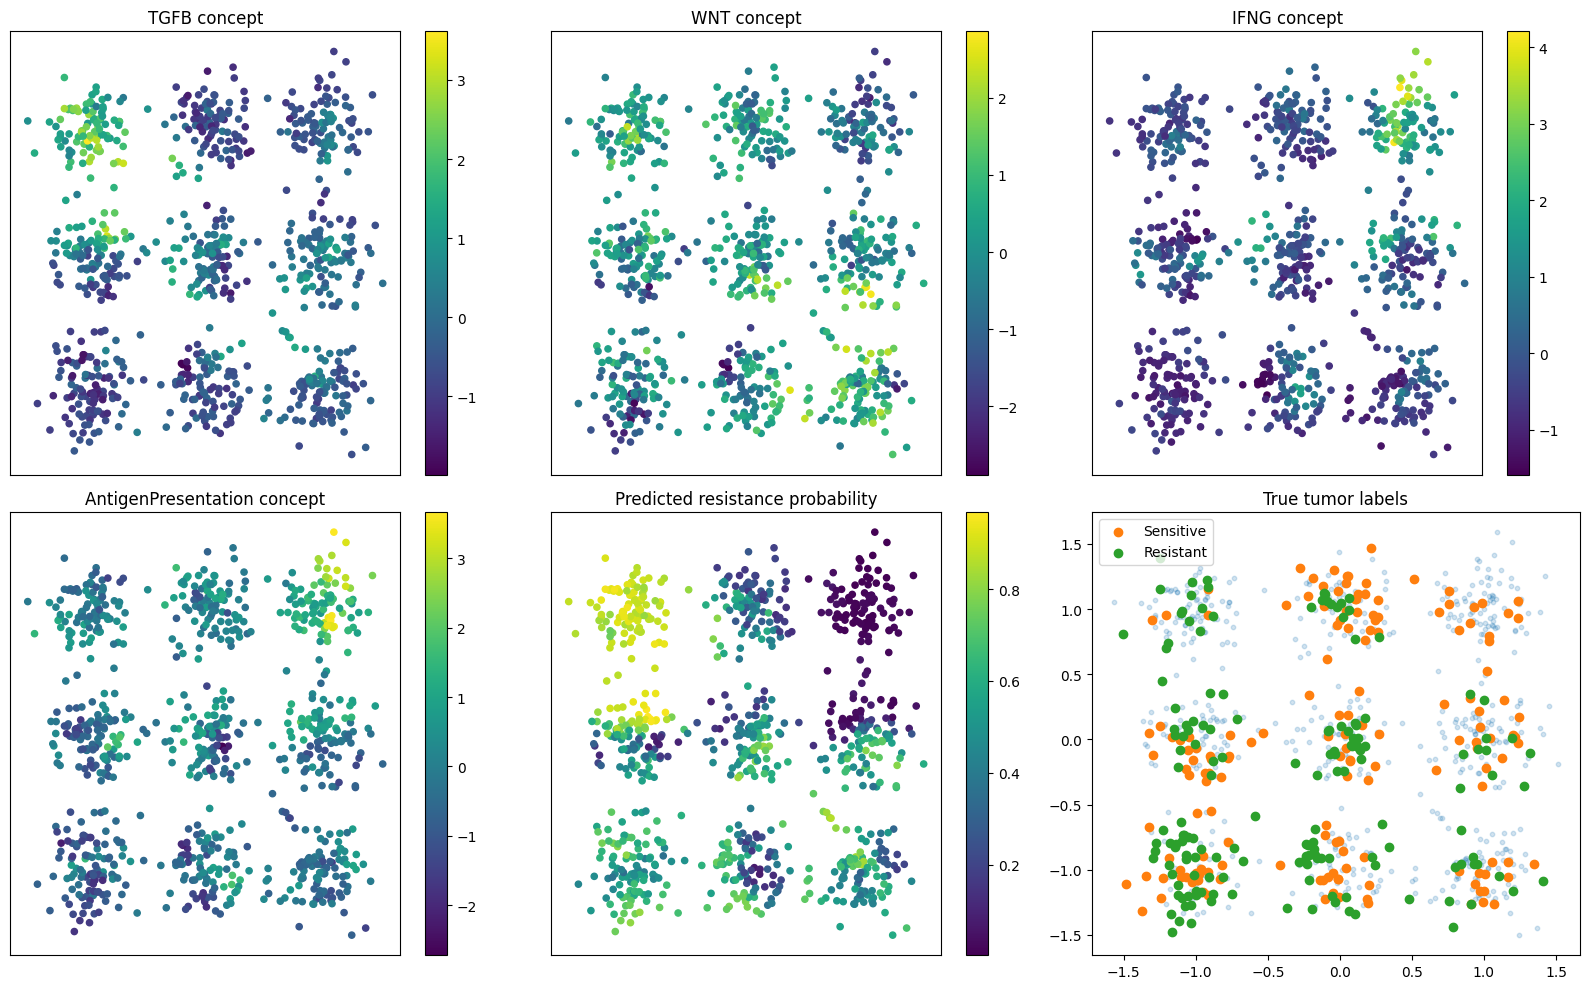

Test metrics: {'f1': 0.7575757575757576, 'auroc': 0.8219832735961768, 'auprc': 0.8199645541827699}


In [34]:
# CELL 21 — Plot spatial pathway activation maps

# z-score pathway activations
for p in pathway_names:
    v = plot_df[f"concept_{p}"].values
    plot_df[f"{p}_z"] = (v - v.mean())/(v.std()+1e-8)

fig,axes = plt.subplots(2,3,figsize=(16,10))

for i,p in enumerate(pathway_names):

    ax = axes.flat[i]

    sc = ax.scatter(
        plot_df["x"],
        plot_df["y"],
        c=plot_df[f"{p}_z"],
        s=20
    )

    ax.set_title(f"{p} concept")
    ax.set_xticks([])
    ax.set_yticks([])

    plt.colorbar(sc,ax=ax)

# predicted resistance probability
ax = axes[1,1]

sc = ax.scatter(
    plot_df["x"],
    plot_df["y"],
    c=plot_df["pred_prob_resistant"],
    s=20
)

ax.set_title("Predicted resistance probability")
ax.set_xticks([])
ax.set_yticks([])

plt.colorbar(sc,ax=ax)

# tumor labels
ax = axes[1,2]

tumor = plot_df["tumor"]==1
sens = (plot_df["label"]==0)&tumor
res  = (plot_df["label"]==1)&tumor

ax.scatter(plot_df["x"],plot_df["y"],s=10,alpha=0.2)
ax.scatter(plot_df.loc[sens,"x"],plot_df.loc[sens,"y"],label="Sensitive")
ax.scatter(plot_df.loc[res,"x"],plot_df.loc[res,"y"],label="Resistant")

ax.set_title("True tumor labels")
ax.legend()

plt.tight_layout()
plt.show()

print("Test metrics:",viz_result["metrics"])

# 15. Communication Motif Landscape

Tumor nodes are projected into a low-dimensional motif space defined by pathway contrasts.

Axes:

Stromal resistance axis  
TGFB − IFNG

Program balance axis  
WNT − AntigenPresentation

This reveals ecological regimes associated with tumor resistance.

### Step 46

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


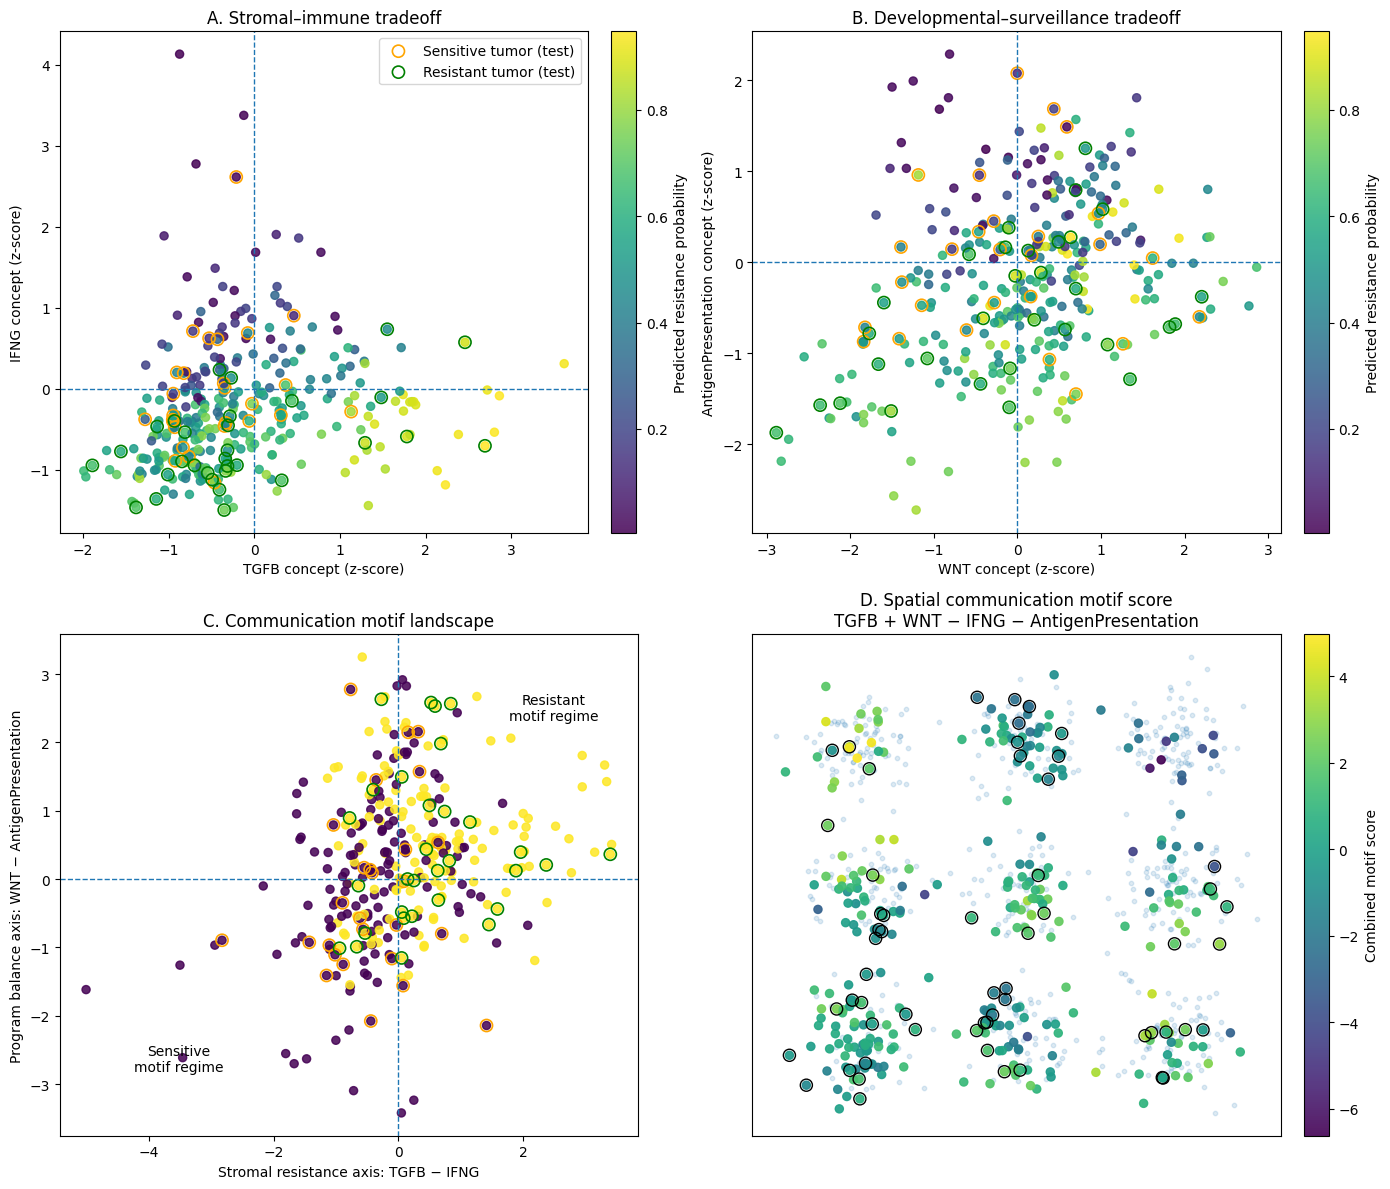

Central communication-motif summary (tumor nodes):
                  tgfb    wnt   ifng     ap  stromal_resistance_axis  program_balance_axis  combined_motif_score  pred_prob_resistant
label                                                                                                                                
Sensitive tumor -0.287  0.093  0.108  0.120                   -0.395                -0.028                -0.423                0.366
Resistant tumor -0.022  0.021 -0.576 -0.517                    0.554                 0.538                 1.092                0.647
Cell 22 ready. motif_df created for Cell 23.


In [35]:
# CELL 22 — Central motif-discovery figure
# Produces the motif landscape used by Cell 23

import matplotlib.pyplot as plt

motif_df = plot_df.loc[plot_df["tumor"] == 1].copy()

# Tumor-only concept axes
motif_df["tgfb"] = motif_df["concept_TGFB_z"]
motif_df["wnt"] = motif_df["concept_WNT_z"]
motif_df["ifng"] = motif_df["concept_IFNG_z"]
motif_df["ap"] = motif_df["concept_AntigenPresentation_z"]

# Interpretable motif scores
motif_df["stromal_resistance_axis"] = motif_df["tgfb"] - motif_df["ifng"]
motif_df["program_balance_axis"] = motif_df["wnt"] - motif_df["ap"]
motif_df["combined_motif_score"] = (
    motif_df["tgfb"] + motif_df["wnt"] - motif_df["ifng"] - motif_df["ap"]
)

# Restrict to labeled tumor nodes
motif_df = motif_df[motif_df["label"] >= 0].copy()

# Helpful subsets
test_tumor_df = motif_df[motif_df["test_tumor"] == 1].copy()
sens_df = test_tumor_df[test_tumor_df["label"] == 0]
res_df = test_tumor_df[test_tumor_df["label"] == 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel A: TGFB vs IFNG
ax = axes[0, 0]
sc = ax.scatter(
    motif_df["tgfb"],
    motif_df["ifng"],
    c=motif_df["pred_prob_resistant"],
    s=34,
    alpha=0.85,
)
ax.axvline(0.0, linestyle="--", linewidth=1.0)
ax.axhline(0.0, linestyle="--", linewidth=1.0)

ax.scatter(
    sens_df["tgfb"],
    sens_df["ifng"],
    facecolors="none",
    edgecolors="orange",
    s=76,
    linewidths=1.2,
    label="Sensitive tumor (test)",
)
ax.scatter(
    res_df["tgfb"],
    res_df["ifng"],
    facecolors="none",
    edgecolors="green",
    s=76,
    linewidths=1.2,
    label="Resistant tumor (test)",
)

ax.set_xlabel("TGFB concept (z-score)")
ax.set_ylabel("IFNG concept (z-score)")
ax.set_title("A. Stromal–immune tradeoff")
ax.legend(loc="best", frameon=True)
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Predicted resistance probability")

# Panel B: WNT vs Antigen Presentation
ax = axes[0, 1]
sc = ax.scatter(
    motif_df["wnt"],
    motif_df["ap"],
    c=motif_df["pred_prob_resistant"],
    s=34,
    alpha=0.85,
)
ax.axvline(0.0, linestyle="--", linewidth=1.0)
ax.axhline(0.0, linestyle="--", linewidth=1.0)

ax.scatter(
    sens_df["wnt"],
    sens_df["ap"],
    facecolors="none",
    edgecolors="orange",
    s=76,
    linewidths=1.2,
)
ax.scatter(
    res_df["wnt"],
    res_df["ap"],
    facecolors="none",
    edgecolors="green",
    s=76,
    linewidths=1.2,
)

ax.set_xlabel("WNT concept (z-score)")
ax.set_ylabel("AntigenPresentation concept (z-score)")
ax.set_title("B. Developmental–surveillance tradeoff")
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Predicted resistance probability")

# Panel C: motif landscape
ax = axes[1, 0]
label_colors = motif_df["label"].map({0: 0.0, 1: 1.0}).to_numpy()

sc = ax.scatter(
    motif_df["stromal_resistance_axis"],
    motif_df["program_balance_axis"],
    c=label_colors,
    s=34,
    alpha=0.85,
)

ax.axvline(0.0, linestyle="--", linewidth=1.0)
ax.axhline(0.0, linestyle="--", linewidth=1.0)

ax.scatter(
    sens_df["stromal_resistance_axis"],
    sens_df["program_balance_axis"],
    facecolors="none",
    edgecolors="orange",
    s=76,
    linewidths=1.2,
)
ax.scatter(
    res_df["stromal_resistance_axis"],
    res_df["program_balance_axis"],
    facecolors="none",
    edgecolors="green",
    s=76,
    linewidths=1.2,
)

ax.set_xlabel("Stromal resistance axis: TGFB − IFNG")
ax.set_ylabel("Program balance axis: WNT − AntigenPresentation")
ax.set_title("C. Communication motif landscape")

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

ax.text(0.65 * x_max, 0.70 * y_max, "Resistant\nmotif regime", ha="center", va="center", fontsize=10)
ax.text(0.65 * x_min, 0.70 * y_min, "Sensitive\nmotif regime", ha="center", va="center", fontsize=10)

# Panel D: spatial map of combined motif score
ax = axes[1, 1]
ax.scatter(
    plot_df["x"],
    plot_df["y"],
    s=10,
    alpha=0.15,
)

sc = ax.scatter(
    motif_df["x"],
    motif_df["y"],
    c=motif_df["combined_motif_score"],
    s=34,
    alpha=0.90,
)

ax.scatter(
    test_tumor_df["x"],
    test_tumor_df["y"],
    facecolors="none",
    edgecolors="black",
    s=76,
    linewidths=1.0,
)

ax.set_title("D. Spatial communication motif score\nTGFB + WNT − IFNG − AntigenPresentation")
ax.set_xticks([])
ax.set_yticks([])
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Combined motif score")

plt.tight_layout()
plt.show()

motif_summary = (
    motif_df.groupby("label")[
        [
            "tgfb",
            "wnt",
            "ifng",
            "ap",
            "stromal_resistance_axis",
            "program_balance_axis",
            "combined_motif_score",
            "pred_prob_resistant",
        ]
    ]
    .mean()
    .rename(index={0: "Sensitive tumor", 1: "Resistant tumor"})
    .round(3)
)

print("Central communication-motif summary (tumor nodes):")
print(motif_summary.to_string())
print("Cell 22 ready. motif_df created for Cell 23.")

# 16. Communication Program Clustering

Continuous pathway signals are clustered to identify discrete tumor microenvironment programs.

These clusters represent recurring ecological niches within the tissue.

### Step 48

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


Communication program pathway signatures:
                  tgfb    wnt   ifng     ap  combined_motif_score
program_cluster                                                  
0               -0.926 -1.212 -0.708 -0.891                -0.539
1                1.329  0.626 -0.321  0.307                 1.968
2               -0.351  0.615 -0.417 -0.515                 1.196
3               -0.276 -0.047  0.873  0.857                -2.053


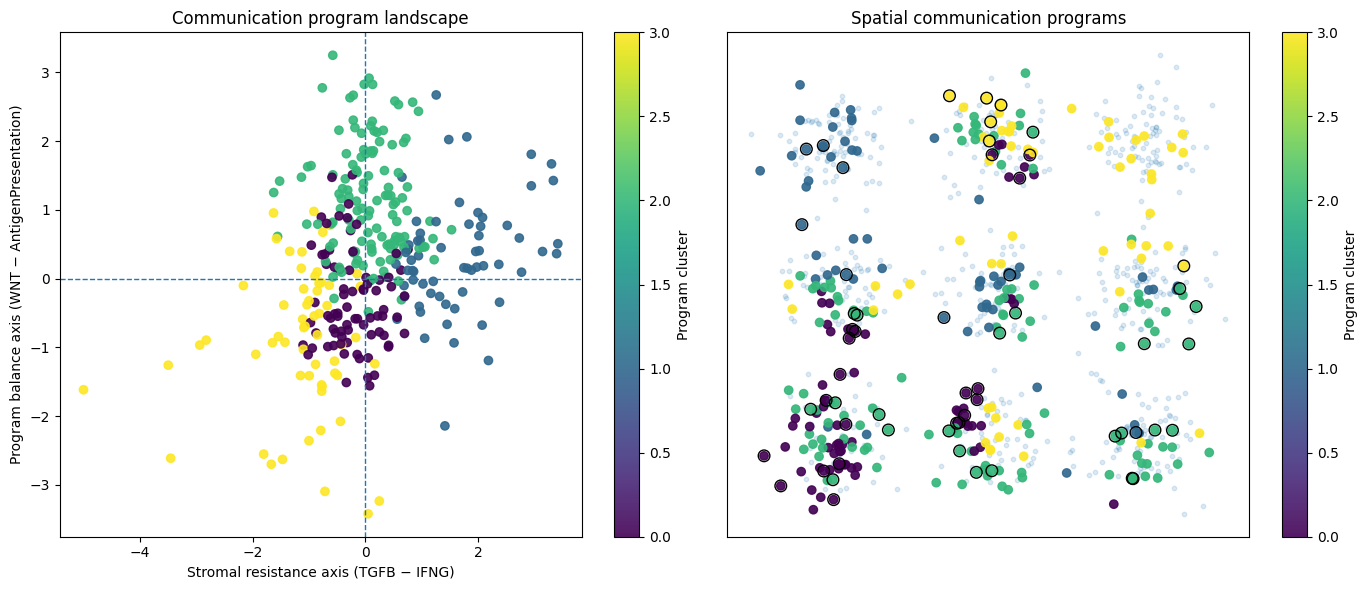


Tumor-state enrichment per program:
label            Sensitive fraction  Resistant fraction
program_cluster                                        
0                             0.462               0.538
1                             0.242               0.758
2                             0.448               0.552
3                             0.932               0.068


In [36]:
# CELL 23 — Communication program clustering (discrete spatial ecological programs)
# Purpose:
#   Convert continuous pathway motif axes into discrete communication programs.
#
# Why this matters:
#   This reveals recurring tumor–microenvironment interaction regimes such as:
#       - stromal-dominant resistant niches
#       - immune-active sensitive niches
#       - mixed transitional ecosystems
#
# This type of plot is commonly used to define tumor microenvironment programs.

from sklearn.cluster import KMeans

# ---------------------------------------------------------
# Feature space for clustering
# ---------------------------------------------------------
program_features = motif_df[
    [
        "tgfb",
        "wnt",
        "ifng",
        "ap",
        "stromal_resistance_axis",
        "program_balance_axis",
    ]
].copy()

# Standardize for clustering stability
prog_mean = program_features.mean()
prog_std = program_features.std() + 1e-8
program_features_z = (program_features - prog_mean) / prog_std

# ---------------------------------------------------------
# KMeans clustering
# ---------------------------------------------------------
N_PROGRAMS = 4

kmeans = KMeans(
    n_clusters=N_PROGRAMS,
    random_state=42,
    n_init=20,
)

motif_df["program_cluster"] = kmeans.fit_predict(program_features_z)

# ---------------------------------------------------------
# Cluster-level pathway summary
# ---------------------------------------------------------
cluster_summary = (
    motif_df.groupby("program_cluster")[["tgfb", "wnt", "ifng", "ap", "combined_motif_score"]]
    .mean()
    .round(3)
)

print("Communication program pathway signatures:")
print(cluster_summary.to_string())

# ---------------------------------------------------------
# Cluster spatial visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A — program landscape
ax = axes[0]

sc = ax.scatter(
    motif_df["stromal_resistance_axis"],
    motif_df["program_balance_axis"],
    c=motif_df["program_cluster"],
    s=36,
    alpha=0.9,
)

ax.axvline(0.0, linestyle="--", linewidth=1)
ax.axhline(0.0, linestyle="--", linewidth=1)

ax.set_xlabel("Stromal resistance axis (TGFB − IFNG)")
ax.set_ylabel("Program balance axis (WNT − AntigenPresentation)")
ax.set_title("Communication program landscape")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Program cluster")

# Panel B — spatial program map
ax = axes[1]

ax.scatter(
    plot_df["x"],
    plot_df["y"],
    s=10,
    alpha=0.15,
)

sc = ax.scatter(
    motif_df["x"],
    motif_df["y"],
    c=motif_df["program_cluster"],
    s=36,
    alpha=0.9,
)

test_nodes = motif_df[motif_df["test_tumor"] == 1]

ax.scatter(
    test_nodes["x"],
    test_nodes["y"],
    facecolors="none",
    edgecolors="black",
    s=70,
    linewidths=1,
)

ax.set_title("Spatial communication programs")
ax.set_xticks([])
ax.set_yticks([])

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Program cluster")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Tumor-state enrichment per program
# ---------------------------------------------------------
program_enrichment = (
    motif_df.groupby("program_cluster")["label"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns={0: "Sensitive fraction", 1: "Resistant fraction"})
    .round(3)
)

print("\nTumor-state enrichment per program:")
print(program_enrichment.to_string())

# 17. Program recovery validation

### compare true communication programs vs model-recovered programs


### Step 50

#### What this cell does
This step executes part of the computational pipeline. Carefully inspect:
- Inputs being used (data, parameters, model components)
- Transformations applied
- Outputs generated

#### Why this matters scientifically
This contributes to testing whether predictions depend on:
- true spatial structure
- pathway-informed signaling
- or unintended shortcuts (e.g., composition leakage)

#### How to interpret outputs
- Outputs should align with expected structure from the simulation
- Unexpectedly strong performance in null settings suggests shortcut learning
- Degradation under falsification supports causal reliance on structure

#### Key check
Ask: *Would this still work if spatial or pathway structure were broken?*


Program recovery metrics:
                            metric  value
                               ARI 0.1774
                               NMI 0.2237
Hungarian-aligned cluster accuracy 0.4846

Aligned cluster overlap (row-normalized):
model_cluster_aligned      0      1      2      3
true_cluster                                     
0                      0.200  0.200  0.267  0.333
1                      0.165  0.495  0.341  0.000
2                      0.376  0.034  0.556  0.034
3                      0.125  0.018  0.232  0.625


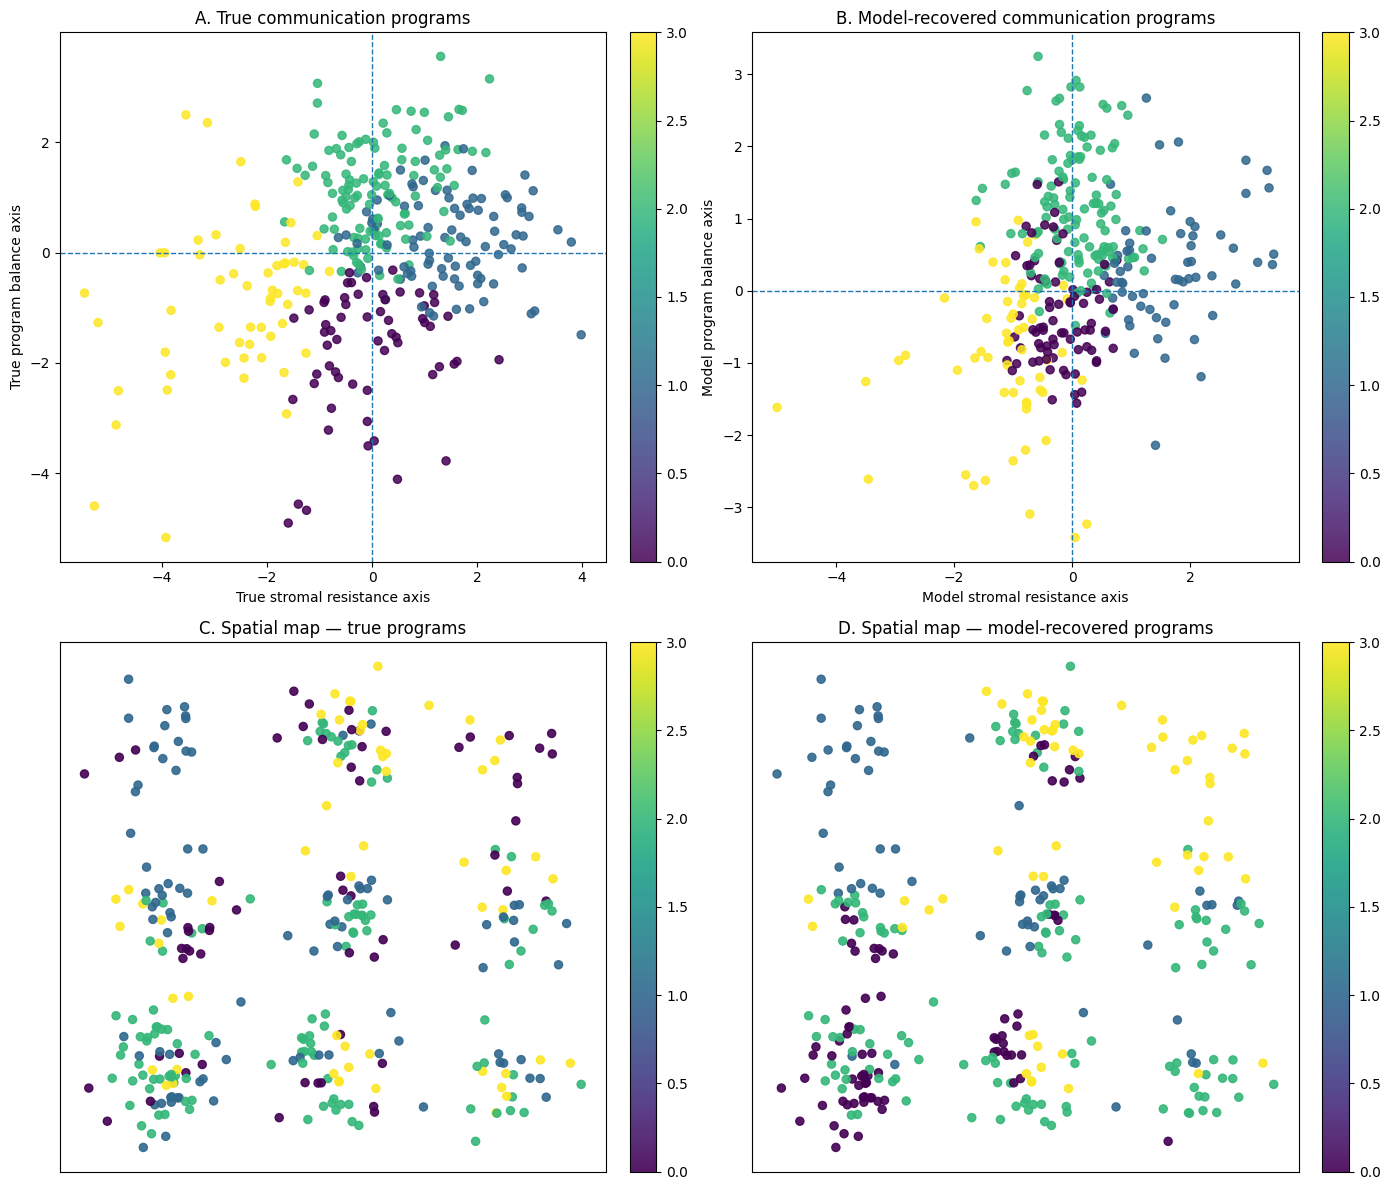


Recovered-program tumor-state enrichment:
label                  Sensitive fraction  Resistant fraction
model_cluster_aligned                                        
0                                   0.462               0.538
1                                   0.242               0.758
2                                   0.448               0.552
3                                   0.932               0.068


In [37]:
# CELL 24 — Robust program recovery validation
# Works whether motif_df came from Cell 22 or the fallback clustering cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from scipy.optimize import linear_sum_assignment

# ---------------------------------------------------------
# 1. Build TRUE communication programs from ground-truth exposures
# ---------------------------------------------------------
cfg = Phase1BConfig(**{**PHASE1B_CONFIG.__dict__, "seed": 11})
set_seed(cfg.seed)

_, true_node_df = generate_phase1b_true_world(cfg)

true_prog_df = true_node_df[
    (true_node_df["is_tumor"] == 1) & (true_node_df["label"] >= 0)
].copy().reset_index(drop=True)

for src, dst in [
    ("recv_TGFB", "true_tgfb"),
    ("recv_WNT", "true_wnt"),
    ("recv_IFNG", "true_ifng"),
    ("recv_AntigenPresentation", "true_ap"),
]:
    vals = true_prog_df[src].to_numpy(dtype=float)
    true_prog_df[dst] = (vals - vals.mean()) / (vals.std() + 1e-8)

true_prog_df["true_stromal_axis"] = true_prog_df["true_tgfb"] - true_prog_df["true_ifng"]
true_prog_df["true_balance_axis"] = true_prog_df["true_wnt"] - true_prog_df["true_ap"]

true_cluster_features = true_prog_df[
    ["true_tgfb", "true_wnt", "true_ifng", "true_ap", "true_stromal_axis", "true_balance_axis"]
].copy()
true_cluster_features = (true_cluster_features - true_cluster_features.mean()) / (true_cluster_features.std() + 1e-8)

k_true = KMeans(n_clusters=4, random_state=42, n_init=20)
true_prog_df["true_cluster"] = k_true.fit_predict(true_cluster_features)

# ---------------------------------------------------------
# 2. Normalize motif_df column names from whatever path created it
# ---------------------------------------------------------
model_prog_df = motif_df.copy().reset_index(drop=True)

# coordinate columns
if "x" not in model_prog_df.columns and "x_coord" in model_prog_df.columns:
    model_prog_df["x"] = model_prog_df["x_coord"]
if "y" not in model_prog_df.columns and "y_coord" in model_prog_df.columns:
    model_prog_df["y"] = model_prog_df["y_coord"]

# optional column
if "pred_prob_resistant" not in model_prog_df.columns:
    model_prog_df["pred_prob_resistant"] = np.nan

# make sure model clusters exist
if "model_cluster" not in model_prog_df.columns:
    model_cluster_features = model_prog_df[
        ["tgfb", "wnt", "ifng", "ap", "stromal_resistance_axis", "program_balance_axis"]
    ].copy()
    model_cluster_features = (model_cluster_features - model_cluster_features.mean()) / (model_cluster_features.std() + 1e-8)

    k_model = KMeans(n_clusters=4, random_state=42, n_init=20)
    model_prog_df["model_cluster"] = k_model.fit_predict(model_cluster_features)

# ---------------------------------------------------------
# 3. Merge true vs model programs
# ---------------------------------------------------------
true_merge_df = true_prog_df.rename(columns={"x_coord": "x", "y_coord": "y"})

merged = pd.merge(
    true_merge_df[["x", "y", "label", "true_cluster", "true_stromal_axis", "true_balance_axis"]],
    model_prog_df[["x", "y", "label", "model_cluster", "stromal_resistance_axis", "program_balance_axis", "pred_prob_resistant"]],
    on=["x", "y", "label"],
    how="inner",
)

# ---------------------------------------------------------
# 4. Agreement metrics
# ---------------------------------------------------------
ari = adjusted_rand_score(merged["true_cluster"], merged["model_cluster"])
nmi = normalized_mutual_info_score(merged["true_cluster"], merged["model_cluster"])

cm = confusion_matrix(merged["true_cluster"], merged["model_cluster"])
row_ind, col_ind = linear_sum_assignment(-cm)
cluster_mapping = {model_c: true_c for true_c, model_c in zip(row_ind, col_ind)}

merged["model_cluster_aligned"] = merged["model_cluster"].map(cluster_mapping)

aligned_cm = confusion_matrix(merged["true_cluster"], merged["model_cluster_aligned"])
cluster_accuracy = aligned_cm.trace() / aligned_cm.sum()

recovery_summary = pd.DataFrame({
    "metric": ["ARI", "NMI", "Hungarian-aligned cluster accuracy"],
    "value": [ari, nmi, cluster_accuracy],
}).round(4)

cluster_overlap = pd.crosstab(
    merged["true_cluster"],
    merged["model_cluster_aligned"],
    normalize="index"
).round(3)

print("Program recovery metrics:")
print(recovery_summary.to_string(index=False))

print("\nAligned cluster overlap (row-normalized):")
print(cluster_overlap.to_string())

# ---------------------------------------------------------
# 5. Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# A. True programs
ax = axes[0, 0]
sc = ax.scatter(
    merged["true_stromal_axis"],
    merged["true_balance_axis"],
    c=merged["true_cluster"],
    s=34,
    alpha=0.85,
)
ax.axvline(0.0, linestyle="--", linewidth=1.0)
ax.axhline(0.0, linestyle="--", linewidth=1.0)
ax.set_xlabel("True stromal resistance axis")
ax.set_ylabel("True program balance axis")
ax.set_title("A. True communication programs")
plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# B. Model programs
ax = axes[0, 1]
sc = ax.scatter(
    merged["stromal_resistance_axis"],
    merged["program_balance_axis"],
    c=merged["model_cluster_aligned"],
    s=34,
    alpha=0.85,
)
ax.axvline(0.0, linestyle="--", linewidth=1.0)
ax.axhline(0.0, linestyle="--", linewidth=1.0)
ax.set_xlabel("Model stromal resistance axis")
ax.set_ylabel("Model program balance axis")
ax.set_title("B. Model-recovered communication programs")
plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# C. True spatial map
ax = axes[1, 0]
sc = ax.scatter(
    merged["x"],
    merged["y"],
    c=merged["true_cluster"],
    s=34,
    alpha=0.9,
)
ax.set_title("C. Spatial map — true programs")
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# D. Model spatial map
ax = axes[1, 1]
sc = ax.scatter(
    merged["x"],
    merged["y"],
    c=merged["model_cluster_aligned"],
    s=34,
    alpha=0.9,
)
ax.set_title("D. Spatial map — model-recovered programs")
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

phenotype_summary = (
    merged.groupby("model_cluster_aligned")["label"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0)
    .rename(columns={0: "Sensitive fraction", 1: "Resistant fraction"})
    .round(3)
)

print("\nRecovered-program tumor-state enrichment:")
print(phenotype_summary.to_string())

#### Output interpretation
- Compare results to falsification expectations
- Look for separation between TRUE vs NULL conditions
- Strong separation indicates meaningful signal usage


## Final Interpretation (Research-Level)

### What was demonstrated
- The model’s performance depends on structured spatial signaling
- Falsification confirms that predictive power is not driven by trivial correlations

### Key methodological insight
Without careful design, models can exploit:
- neighbor composition
- latent leakage
rather than true communication pathways

### Contribution of this workflow
- Establishes a falsification-based validation framework
- Improves identifiability through architectural constraints
- Recovers interpretable signaling programs

### Scientific claim
Resistance is an emergent property of **structured multicellular signaling ecosystems**, not solely intrinsic cell state.

### Recommended next steps
- Apply to real spatial transcriptomics datasets
- Validate biological plausibility of learned pathways
- Benchmark against non-spatial and black-box baselines


In [39]:
# Cell — Inspect available variables for export

vars_list = sorted([k for k in globals().keys() if not k.startswith("_")])

for v in vars_list:
    obj = globals()[v]
    try:
        shape = getattr(obj, "shape", None)
        if shape is not None:
            print(f"{v:40s}  shape={shape}")
        elif isinstance(obj, (list, dict)):
            print(f"{v:40s}  type={type(obj).__name__}  len={len(obj)}")
    except:
        print(v)
        

CONFIG                                    type=dict  len=9
In                                        type=list  len=40
Out                                       type=dict  len=0
PATHWAY_NAMES                             type=list  len=4
PHASE1B_BACKGROUND_GENES                  type=list  len=48
PHASE1B_CELL_TYPES                        type=list  len=5
PHASE1B_CELL_TYPE_TO_ID                   type=dict  len=5
PHASE1B_EXPECTED_DIRECTIONS               type=dict  len=4
PHASE1B_GENES                             type=list  len=72
PHASE1B_GENE_TO_ID                        type=dict  len=72
PHASE1B_PATHWAYS                          type=list  len=4
PHASE1B_PATHWAY_GENE_MAP                  type=dict  len=4
PHASE1B_SUCCESS_CRITERIA                  type=dict  len=3
PHASE1C_EMISSION_MIXTURE                  shape=(5, 4)
SEED_LIST                                 type=list  len=3
TRUE_PATHWAY_MASK                         shape=torch.Size([72, 4])
W                                         shape

In [40]:
# Cell — Export prototype figure artifacts

import os
import pickle
import numpy as np
import pandas as pd
import torch

EXPORT_DIR = "/Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype"
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_df(obj, name):
    path = os.path.join(EXPORT_DIR, name)
    if isinstance(obj, pd.DataFrame):
        obj.to_csv(path, index=False)
    else:
        pd.DataFrame(obj).to_csv(path, index=False)
    print("saved:", path)

def save_npy(obj, name):
    path = os.path.join(EXPORT_DIR, name)
    if torch.is_tensor(obj):
        obj = obj.detach().cpu().numpy()
    else:
        obj = np.asarray(obj)
    np.save(path, obj)
    print("saved:", path)

def save_pkl(obj, name):
    path = os.path.join(EXPORT_DIR, name)
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print("saved:", path)

# -------------------------
# Explicit known artifacts
# -------------------------
explicit_exports = [
    "ablation_results",
    "align_df",
    "aligned_cm",
    "alignment_rows",
    "baseline_views",
    "PHASE1C_EMISSION_MIXTURE",
    "TRUE_PATHWAY_MASK",
    "W",
    "W_eval",
    "W_final",
    "PATHWAY_NAMES",
    "PHASE1B_EXPECTED_DIRECTIONS",
    "PHASE1B_SUCCESS_CRITERIA",
    "SEED_LIST",
    "CONFIG",
]

for var_name in explicit_exports:
    if var_name in globals():
        obj = globals()[var_name]
        if isinstance(obj, pd.DataFrame):
            save_df(obj, f"{var_name}.csv")
        elif torch.is_tensor(obj) or isinstance(obj, np.ndarray):
            save_npy(obj, f"{var_name}.npy")
        elif isinstance(obj, (list, dict, tuple)):
            save_pkl(obj, f"{var_name}.pkl")

# -------------------------
# Auto-export likely figure artifacts
# -------------------------
keywords = [
    "result", "results", "summary", "table", "rows", "df", "metric",
    "view", "views", "coords", "coord", "edge", "graph", "mask",
    "cluster", "motif", "program", "pathway", "align", "cm"
]

skip_vars = {
    "In", "Out", "os", "np", "pd", "pickle", "torch",
    "save_df", "save_npy", "save_pkl", "EXPORT_DIR",
    "explicit_exports", "keywords", "skip_vars", "var_name", "obj"
}

for var_name, obj in sorted(globals().items()):
    if var_name in skip_vars or var_name.startswith("_"):
        continue
    if var_name in explicit_exports:
        continue

    lower = var_name.lower()
    if not any(k in lower for k in keywords):
        continue

    try:
        if isinstance(obj, pd.DataFrame):
            save_df(obj, f"{var_name}.csv")
        elif torch.is_tensor(obj) or isinstance(obj, np.ndarray):
            save_npy(obj, f"{var_name}.npy")
        elif isinstance(obj, (list, dict, tuple)):
            save_pkl(obj, f"{var_name}.pkl")
    except Exception as e:
        print(f"skipped {var_name}: {e}")

print("Prototype export complete.")

saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/ablation_results.csv
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/align_df.csv
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/aligned_cm.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/alignment_rows.pkl
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/baseline_views.pkl
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/PHASE1C_EMISSION_MIXTURE.csv
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/TRUE_PATHWAY_MASK.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/W.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/W_eval.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototype/W_final.npy
saved: /Users/sally/Desktop/Prototype_validation/figure_artifacts/prototy